conda activate ai    떠 있으면 또 안해도 됨
pip install ipykernel

In [1]:
import torch
print(torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3060


In [2]:
# 데이터를 불러오고 살펴보기 위한 pandas 라이브러리를 import 
import pandas as pd

# train 이라는 객체에 'train.csv' 파일을 할당 해 줌
train  = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [3]:
# train 데이터의 상위 5개 행을 출력
train.head()

,transaction_id,apartment_id,city,dong,jibun,apt,addr_kr,exclusive_use_area,year_of_completion,transaction_year_month,transaction_date,floor,transaction_real_price
0,0,7622,서울특별시,신교동,6-13,신현(101동),신교동 6-13 신현(101동),84.82,2002,200801,21~31,2,37500
1,1,5399,서울특별시,필운동,142,사직파크맨션,필운동 142 사직파크맨션,99.17,1973,200801,1~10,6,20000
2,2,3578,서울특별시,필운동,174-1,두레엘리시안,필운동 174-1 두레엘리시안,84.74,2007,200801,1~10,6,38500
3,3,10957,서울특별시,내수동,95,파크팰리스,내수동 95 파크팰리스,146.39,2003,200801,11~20,15,118000
4,4,10639,서울특별시,내수동,110-15,킹스매너,내수동 110-15 킹스매너,194.43,2004,200801,21~31,3,120000


In [4]:
# train 데이터의 전체적인 정보를 요약해서 보여줍니다.
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1216553 entries, 0 to 1216552
Data columns (total 13 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   transaction_id          1216553 non-null  int64  
 1   apartment_id            1216553 non-null  int64  
 2   city                    1216553 non-null  object 
 3   dong                    1216553 non-null  object 
 4   jibun                   1216553 non-null  object 
 5   apt                     1216553 non-null  object 
 6   addr_kr                 1216553 non-null  object 
 7   exclusive_use_area      1216553 non-null  float64
 8   year_of_completion      1216553 non-null  int64  
 9   transaction_year_month  1216553 non-null  int64  
 10  transaction_date        1216553 non-null  object 
 11  floor                   1216553 non-null  int64  
 12  transaction_real_price  1216553 non-null  int64  
dtypes: float64(1), int64(6), object(6)
memory usage: 120.7+ M

In [5]:
# 각 컬럼별 결측값의 개수를 출력해줍니다.
train.isnull().sum()

transaction_id            0
apartment_id              0
city                      0
dong                      0
jibun                     0
apt                       0
addr_kr                   0
exclusive_use_area        0
year_of_completion        0
transaction_year_month    0
transaction_date          0
floor                     0
transaction_real_price    0
dtype: int64

In [6]:
# 수치형 컬럼의 통계를 요약해 출력해 줍니다. 
train.describe()

,transaction_id,apartment_id,exclusive_use_area,year_of_completion,transaction_year_month,floor,transaction_real_price
count,1.216553e+06,1.216553e+06,1.216553e+06,1.216553e+06,1.216553e+06,1.216553e+06,1.216553e+06
mean,6.091530e+05,6.299685e+03,7.816549e+01,1.998297e+03,2.012984e+05,9.343291e+00,3.822769e+04
std,3.526198e+05,3.581169e+03,2.915113e+01,8.941347e+00,2.905732e+02,6.606500e+00,3.104898e+04
min,0.000000e+00,0.000000e+00,9.260000e+00,1.961000e+03,2.008010e+05,-4.000000e+00,1.000000e+02
25%,3.041380e+05,3.345000e+03,5.976000e+01,1.993000e+03,2.010100e+05,4.000000e+00,1.900000e+04
50%,6.082760e+05,5.964000e+03,8.241000e+01,1.999000e+03,2.013120e+05,8.000000e+00,3.090000e+04
75%,9.124140e+05,9.436000e+03,8.497000e+01,2.005000e+03,2.015110e+05,1.300000e+01,4.700000e+04
max,1.234827e+06,1.265800e+04,4.243200e+02,2.017000e+03,2.017110e+05,8.000000e+01,8.200000e+05


In [7]:
# 점주형 컬럼의 통계를 요약해 출력해줍니다.
train.describe(include=['object'])

,city,dong,jibun,apt,addr_kr,transaction_date
count,1216553,1216553,1216553,1216553,1216553,1216553
unique,2,473,8961,10440,12533,6
top,서울특별시,상계동,176-30,현대,용호동 944 오륙도에스케이뷰,11~20
freq,742285,29346,6594,13154,3220,408385


In [8]:
train['city'].value_counts()

city
서울특별시    742285
부산광역시    474268
Name: count, dtype: int64

In [9]:
train['city'] == '부산광역시'

0          False
1          False
2          False
3          False
4          False
           ...  
1216548     True
1216549     True
1216550     True
1216551     True
1216552     True
Name: city, Length: 1216553, dtype: bool

In [10]:
train[train['city'] == '부산광역시']

,transaction_id,apartment_id,city,dong,jibun,apt,addr_kr,exclusive_use_area,year_of_completion,transaction_year_month,transaction_date,floor,transaction_real_price
650921,650921,3310,부산광역시,영주동,160,동아(160-0),영주동 160 동아(160-0),57.0900,1998,200801,1~10,4,7900
650922,650922,2939,부산광역시,영주동,587,도경오벨리스,영주동 587 도경오벨리스,84.9700,2005,200801,1~10,12,13000
650923,650923,1704,부산광역시,영주동,161,금호,영주동 161 금호,84.8600,1997,200801,11~20,7,12400
650924,650924,3310,부산광역시,영주동,160,동아(160-0),영주동 160 동아(160-0),84.7200,1998,200801,11~20,14,10600
650925,650925,1704,부산광역시,영주동,161,금호,영주동 161 금호,84.5900,1997,200801,21~31,5,10000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1216548,1234823,9578,부산광역시,정관읍 용수리,1387,정관 동일스위트1차,정관읍 용수리 1387 정관 동일스위트1차,59.8245,2012,201711,11~20,3,22000
1216549,1234824,9578,부산광역시,정관읍 용수리,1387,정관 동일스위트1차,정관읍 용수리 1387 정관 동일스위트1차,84.9923,2012,201711,21~30,7,30750
1216550,1234825,9578,부산광역시,정관읍 용수리,1387,정관 동일스위트1차,정관읍 용수리 1387 정관 동일스위트1차,84.9923,2012,201711,21~30,9,29500
1216551,1234826,9586,부산광역시,정관읍 용수리,1364,정관신도시롯데캐슬,정관읍 용수리 1364 정관신도시롯데캐슬,101.7400,2008,201711,21~30,7,26700


In [11]:
train.loc[train['city']=='부산광역시',:]

,transaction_id,apartment_id,city,dong,jibun,apt,addr_kr,exclusive_use_area,year_of_completion,transaction_year_month,transaction_date,floor,transaction_real_price
650921,650921,3310,부산광역시,영주동,160,동아(160-0),영주동 160 동아(160-0),57.0900,1998,200801,1~10,4,7900
650922,650922,2939,부산광역시,영주동,587,도경오벨리스,영주동 587 도경오벨리스,84.9700,2005,200801,1~10,12,13000
650923,650923,1704,부산광역시,영주동,161,금호,영주동 161 금호,84.8600,1997,200801,11~20,7,12400
650924,650924,3310,부산광역시,영주동,160,동아(160-0),영주동 160 동아(160-0),84.7200,1998,200801,11~20,14,10600
650925,650925,1704,부산광역시,영주동,161,금호,영주동 161 금호,84.5900,1997,200801,21~31,5,10000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1216548,1234823,9578,부산광역시,정관읍 용수리,1387,정관 동일스위트1차,정관읍 용수리 1387 정관 동일스위트1차,59.8245,2012,201711,11~20,3,22000
1216549,1234824,9578,부산광역시,정관읍 용수리,1387,정관 동일스위트1차,정관읍 용수리 1387 정관 동일스위트1차,84.9923,2012,201711,21~30,7,30750
1216550,1234825,9578,부산광역시,정관읍 용수리,1387,정관 동일스위트1차,정관읍 용수리 1387 정관 동일스위트1차,84.9923,2012,201711,21~30,9,29500
1216551,1234826,9586,부산광역시,정관읍 용수리,1364,정관신도시롯데캐슬,정관읍 용수리 1364 정관신도시롯데캐슬,101.7400,2008,201711,21~30,7,26700


In [12]:
train.loc[train['city']=='부산광역시',['year_of_completion','transaction_year_month']]

,year_of_completion,transaction_year_month
650921,1998,200801
650922,2005,200801
650923,1997,200801
650924,1998,200801
650925,1997,200801
...,...,...
1216548,2012,201711
1216549,2012,201711
1216550,2012,201711
1216551,2008,201711


In [13]:
train.iloc[:,[8,9]]

,year_of_completion,transaction_year_month
0,2002,200801
1,1973,200801
2,2007,200801
3,2003,200801
4,2004,200801
...,...,...
1216548,2012,201711
1216549,2012,201711
1216550,2012,201711
1216551,2008,201711


In [14]:
train.iloc[9:20,[8,9]]

,year_of_completion,transaction_year_month
9,2006,200801
10,2004,200801
11,2002,200801
12,2003,200801
13,1999,200801
14,1999,200801
15,1999,200801
16,1999,200801
17,1968,200801
18,1999,200801


In [15]:
# 웹 파이썬 
# import micropip
# await micropip.install('seaborn')
# ! : 터미널에서 실행
# !pip install seaborn
# 설치 되어있었음 

In [16]:
# 파이썬 warning 무시
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# 시각화를 위한 라이브러리
# import matplotlib.font_manager as fm  # 폰트매니저

# 한글 폰트를 사용하기 위한 코드
# fe = fm.FontEntry(fname='NotoSansKR-Regular.otf','NotoSansKR')
# fm.fontManager.ttflist.insert(0,fe)   # 폰트 matplotlib 에 추가하는 (맨앞에 추가)
# plt.rc('font', family = 'NotoSansKR')

# 해당 폰트가 없어 윈도우에서 지원하는 폰트 사용 
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("fivethirtyeight")

In [18]:
train = pd.read_csv('train.csv')

In [19]:
train.head(2)

,transaction_id,apartment_id,city,dong,jibun,apt,addr_kr,exclusive_use_area,year_of_completion,transaction_year_month,transaction_date,floor,transaction_real_price
0,0,7622,서울특별시,신교동,6-13,신현(101동),신교동 6-13 신현(101동),84.82,2002,200801,21~31,2,37500
1,1,5399,서울특별시,필운동,142,사직파크맨션,필운동 142 사직파크맨션,99.17,1973,200801,1~10,6,20000


In [20]:
# transaction_year_month 에서 연도와 월을 분리
train['year'] = train['transaction_year_month'].astype(str).str[:4].astype(int)
train['month'] = train['transaction_year_month'].astype(str).str[:4].astype(int)

In [21]:
train.head()

,transaction_id,apartment_id,city,dong,jibun,apt,addr_kr,exclusive_use_area,year_of_completion,transaction_year_month,transaction_date,floor,transaction_real_price,year,month
0,0,7622,서울특별시,신교동,6-13,신현(101동),신교동 6-13 신현(101동),84.82,2002,200801,21~31,2,37500,2008,2008
1,1,5399,서울특별시,필운동,142,사직파크맨션,필운동 142 사직파크맨션,99.17,1973,200801,1~10,6,20000,2008,2008
2,2,3578,서울특별시,필운동,174-1,두레엘리시안,필운동 174-1 두레엘리시안,84.74,2007,200801,1~10,6,38500,2008,2008
3,3,10957,서울특별시,내수동,95,파크팰리스,내수동 95 파크팰리스,146.39,2003,200801,11~20,15,118000,2008,2008
4,4,10639,서울특별시,내수동,110-15,킹스매너,내수동 110-15 킹스매너,194.43,2004,200801,21~31,3,120000,2008,2008


In [22]:
train['transaction_date'].value_counts()

transaction_date
11~20    408385
1~10     391715
21~31    250588
21~30    134017
21~28     22199
21~29      9649
Name: count, dtype: int64

In [23]:
# transaction_date에서 21 ~ 31 , 21 ~ 30, 21~ 28 , 21~29 에 해당하는 값을 21~31로 변환해봅시다.
train.loc[(train['transaction_date'] == '21~30') | (train['transaction_date'] == '21~28') | (train['transaction_date'] == '21~29'),'transaction_date'] = '21~31'

In [24]:
train['transaction_date'].value_counts()

transaction_date
21~31    416453
11~20    408385
1~10     391715
Name: count, dtype: int64

In [25]:
# pie chart 
seoul_busan = train['city'].value_counts()
seoul_busan

city
서울특별시    742285
부산광역시    474268
Name: count, dtype: int64

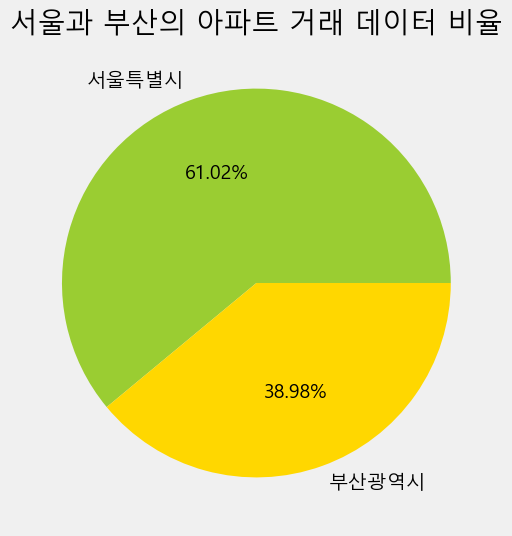

In [26]:
# matplotlib의 plt.pie()를 이용해 파이차트 그리기

color = ['yellowgreen','gold']
langs = ['서울특별시','부산광역시']

plt.figure(figsize = (8,6))
plt.pie(seoul_busan, labels=langs, colors=color, autopct='%.2f%%')
plt.title('서울과 부산의 아파트 거래 데이터 비율', size = 20)
plt.show()

In [27]:
# 연도별 count table 만들기
train_year_count = train['year'].value_counts().sort_index(ascending=True)
train_year_count

year
2008    100066
2009    127869
2010    102823
2011     98586
2012     70065
2013    109738
2014    136649
2015    181195
2016    165664
2017    123898
Name: count, dtype: int64

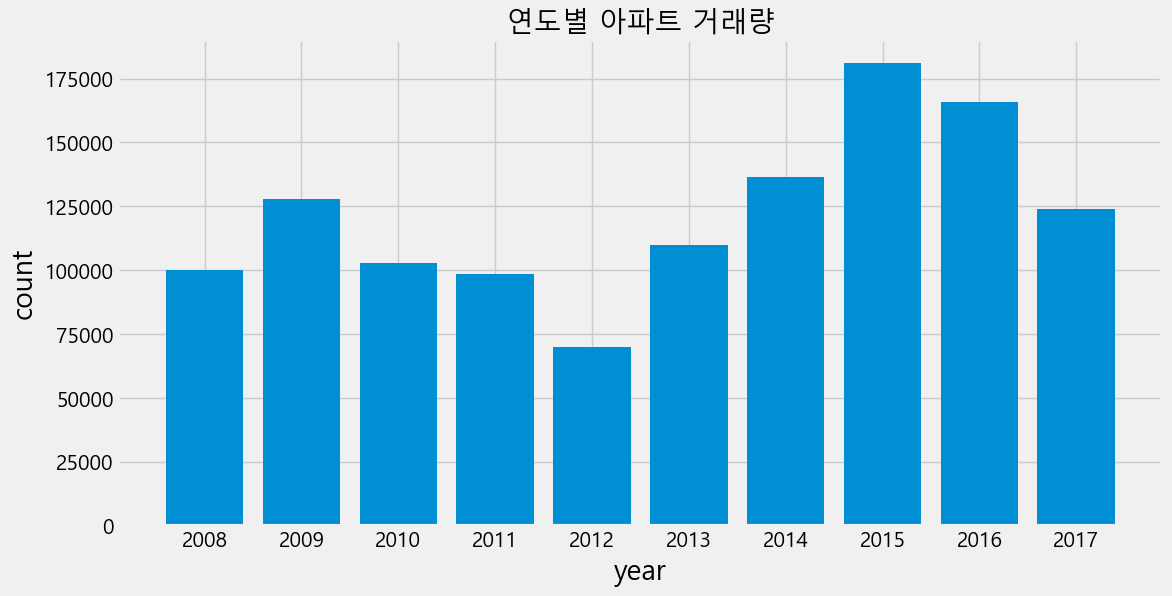

In [28]:
# matplotlib을 이용하여 연도별 아파트 거래량을 나타내기

plt.figure(figsize=(12,6))

plt.bar(train_year_count.index.astype(str), train_year_count.values)
plt.title('연도별 아파트 거래량', size = 20)

plt.xticks(size = 15)
plt.yticks(size = 15)

plt.xlabel('year', size = 20)
plt.ylabel('count',size = 20)

plt.show()

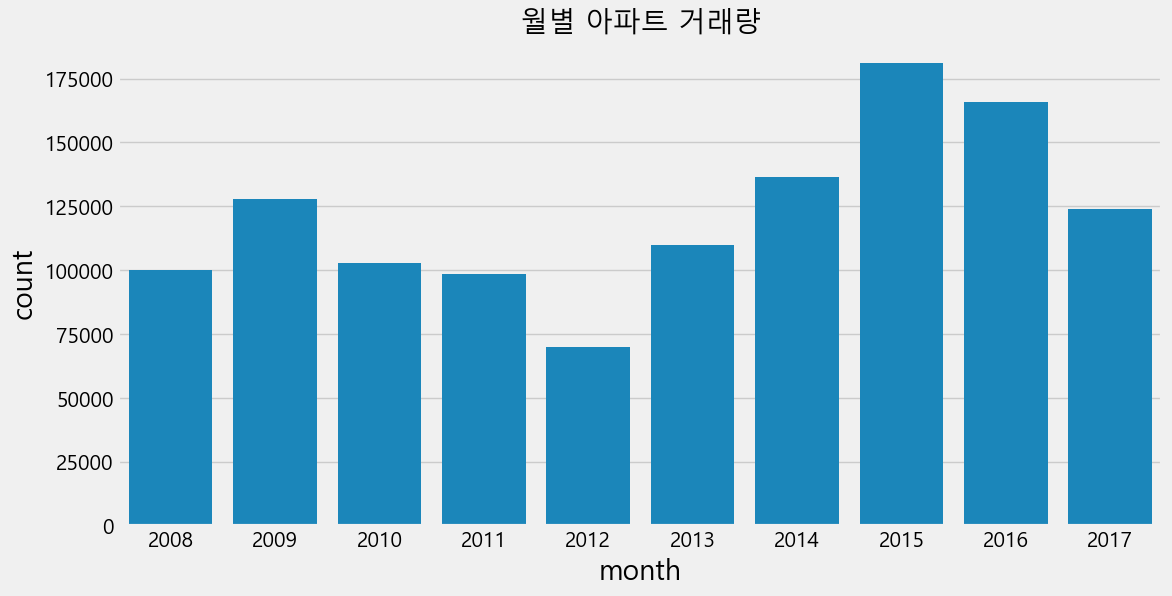

In [29]:
# seaborn 의 countplot 을 이용하여 월별 아파트 거래량을 나타내기

plt.figure(figsize=(12,6))
sns.countplot(x = 'month', data = train)
plt.title('월별 아파트 거래량',size = 20)

plt.xticks(size = 15)
plt.yticks(size = 15)

plt.xlabel('month',size = 20)
plt.ylabel('count', size = 20)

plt.show()

In [30]:
# 일별 count table 을 만들기
train_day_count  = train['transaction_date'].value_counts().sort_index(ascending=False).to_frame()
train_day_count

,count
transaction_date,
21~31,416453
1~10,391715
11~20,408385


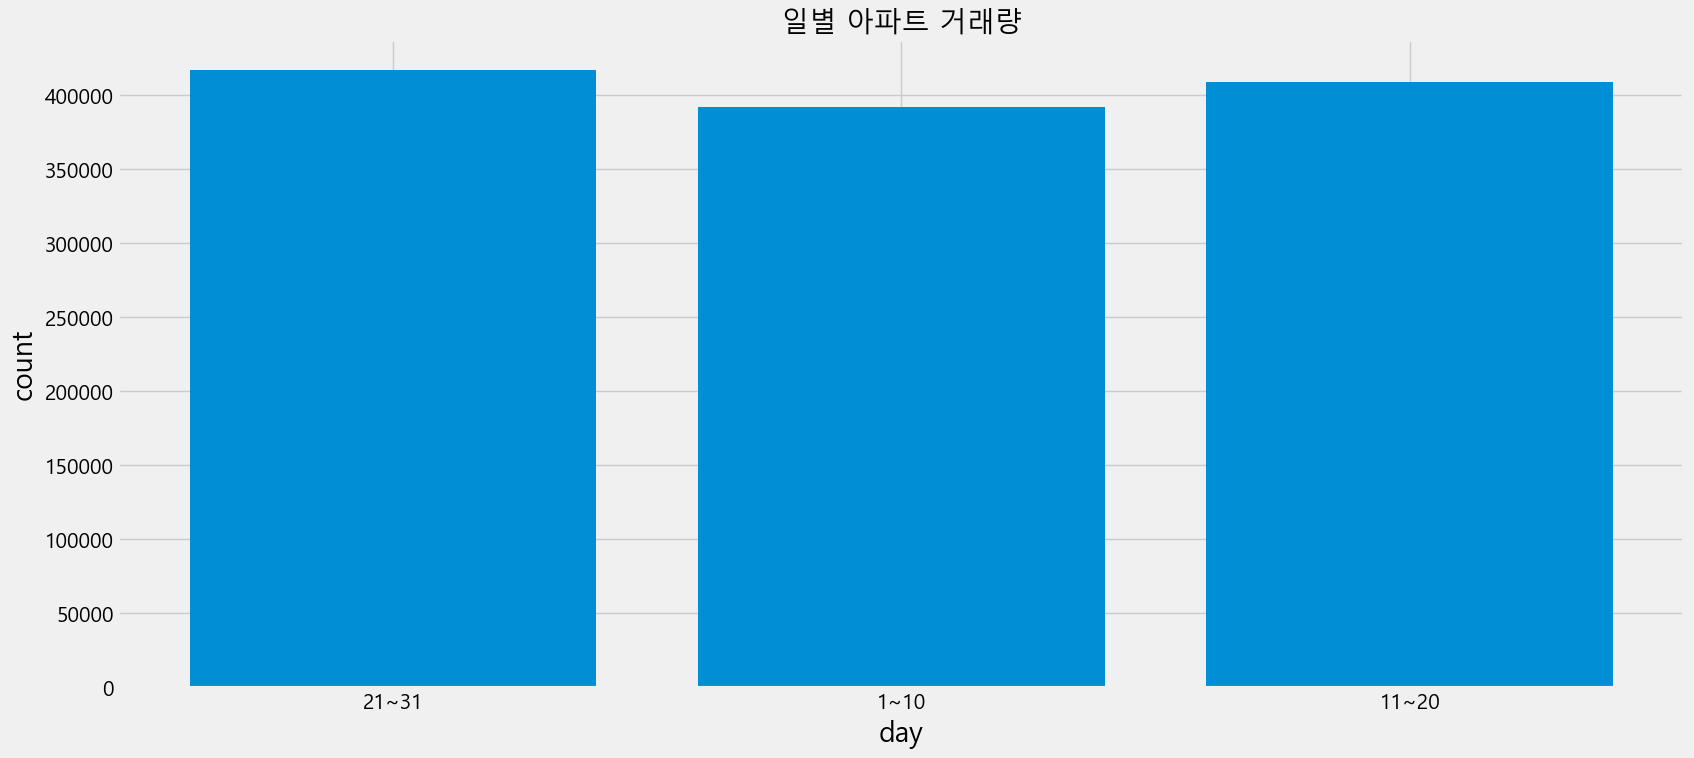

In [31]:
# matplotlib 이용하여 일별 아파트 거래량을 나타내보기

plt.figure(figsize=(18, 8))

train_day_count = train['transaction_date'].value_counts().to_frame('count')
plt.title('일별 아파트 거래량',size = 20)
# 순서정렬 
order = ['21~31', '1~10', '11~20']
train_day_count = train_day_count.reindex(order)

plt.bar(train_day_count.index, train_day_count['count'])

plt.xticks(size=15)
plt.yticks(size=15)
plt.xlabel('day', size=20)
plt.ylabel('count', size=20)

plt.show()

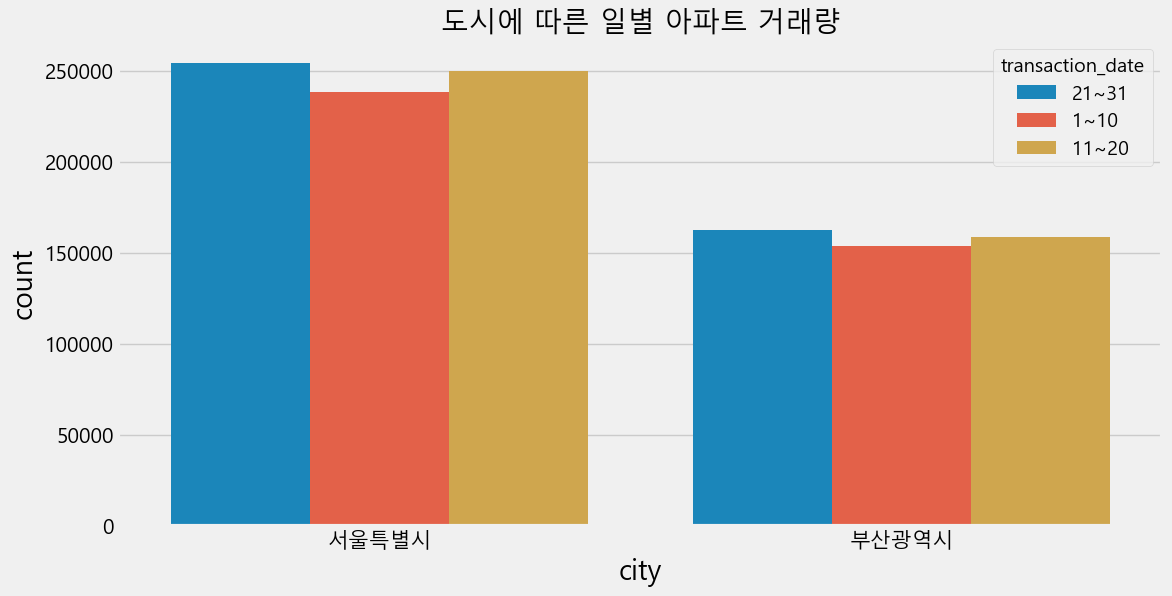

In [32]:
# 이변량 countplot

# seaborn의 countplot 을 이용하여 도시에 따른 일별 거래을 나타내보기 

plt.figure(figsize=(12,6))
sns.countplot(x = 'city', hue = 'transaction_date', data = train)
plt.title('도시에 따른 일별 아파트 거래량', size = 20)

plt.xticks(size = 15)
plt.yticks(size = 15)

plt.xlabel('city', size = 20)
plt.ylabel('count', size = 20)
plt.show()

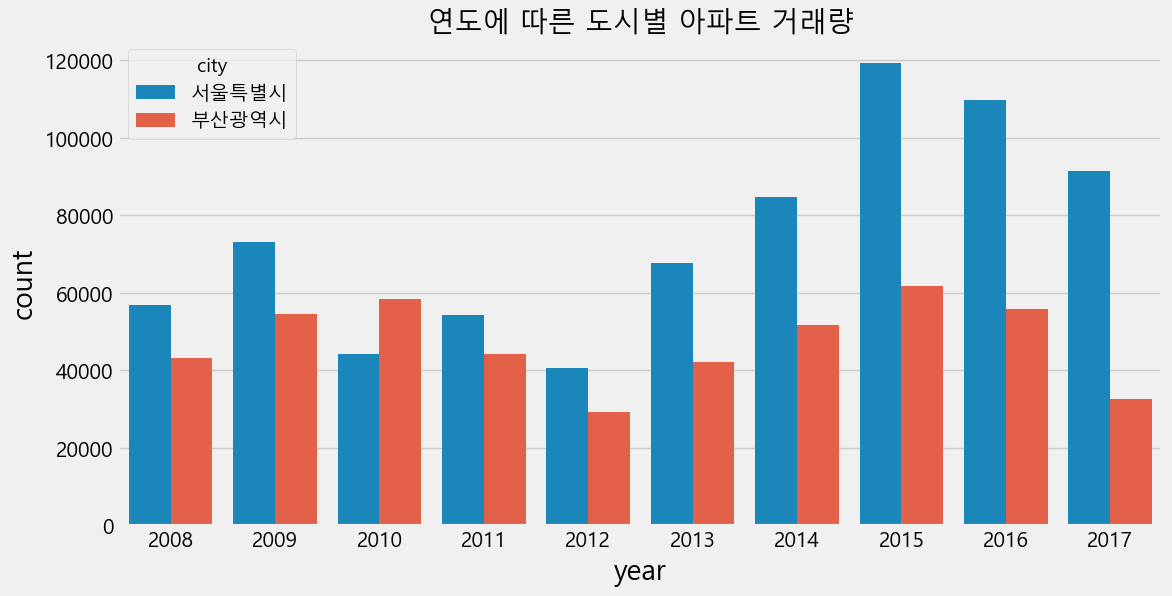

In [33]:
# seaborn 의 countplot 을 이용하여 연도에 따른 도시별 아파트 거래량을 나타내기

plt.figure(figsize=(12,6))
sns.countplot(x='year', hue= 'city', data = train)
plt.title('연도에 따른 도시별 아파트 거래량', size= 20)

plt.xticks(size =15)
plt.yticks(size = 15)

plt.xlabel('year', size = 20)
plt.ylabel('count', size = 20)

plt.show()

In [34]:
# 서울특별시 아파트 평균 거래가 top10 지역
# 서울특별시 데이터만 모아서 출력
seoul_data = train.loc[train['city'] == '서울특별시', :]
seoul_data.head(2)

,transaction_id,apartment_id,city,dong,jibun,apt,addr_kr,exclusive_use_area,year_of_completion,transaction_year_month,transaction_date,floor,transaction_real_price,year,month
0,0,7622,서울특별시,신교동,6-13,신현(101동),신교동 6-13 신현(101동),84.82,2002,200801,21~31,2,37500,2008,2008
1,1,5399,서울특별시,필운동,142,사직파크맨션,필운동 142 사직파크맨션,99.17,1973,200801,1~10,6,20000,2008,2008


In [35]:
# 서울특별시 지역별로 아파트 평균 거래가 pivot table 만들기
price_seoul_dong = (seoul_data.groupby('dong')[['transaction_real_price']].mean())
price_seoul_dong_top_10 = price_seoul_dong.sort_values(['transaction_real_price'], ascending =False)[:10]

In [36]:
price_seoul_dong_top_10

,transaction_real_price
dong,
장충동1가,269888.888889
압구정동,164534.722914
청암동,161403.700000
용산동5가,153497.331633
회현동2가,139906.140351
반포동,132489.395651
한남동,122593.293264
서빙고동,116547.239777
대치동,116320.538909


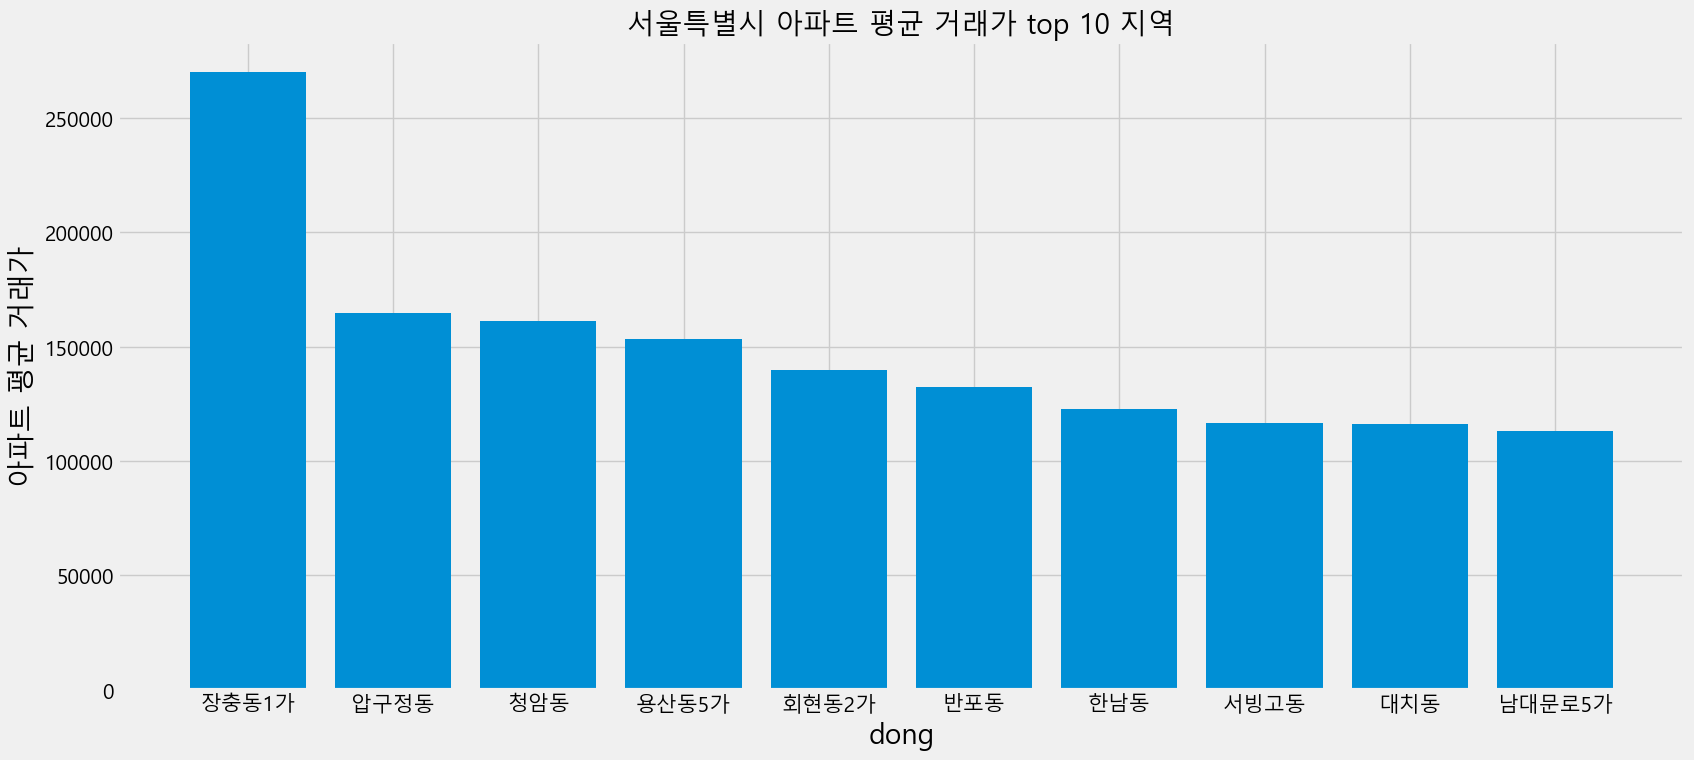

In [37]:
# matplotlib의 bar을 이용하여 서울특별시 아파트 평균거래가가 높은 10개의 지역을 나타내기
plt.figure(figsize=(18,8))
plt.bar(price_seoul_dong_top_10.index, price_seoul_dong_top_10['transaction_real_price'])
plt.title('서울특별시 아파트 평균 거래가 top 10 지역', size = 20)

plt.xticks(size = 15)
plt.yticks(size = 15)

plt.xlabel('dong',size =20)
plt.ylabel('아파트 평균 거래가',size = 20)

plt.show()

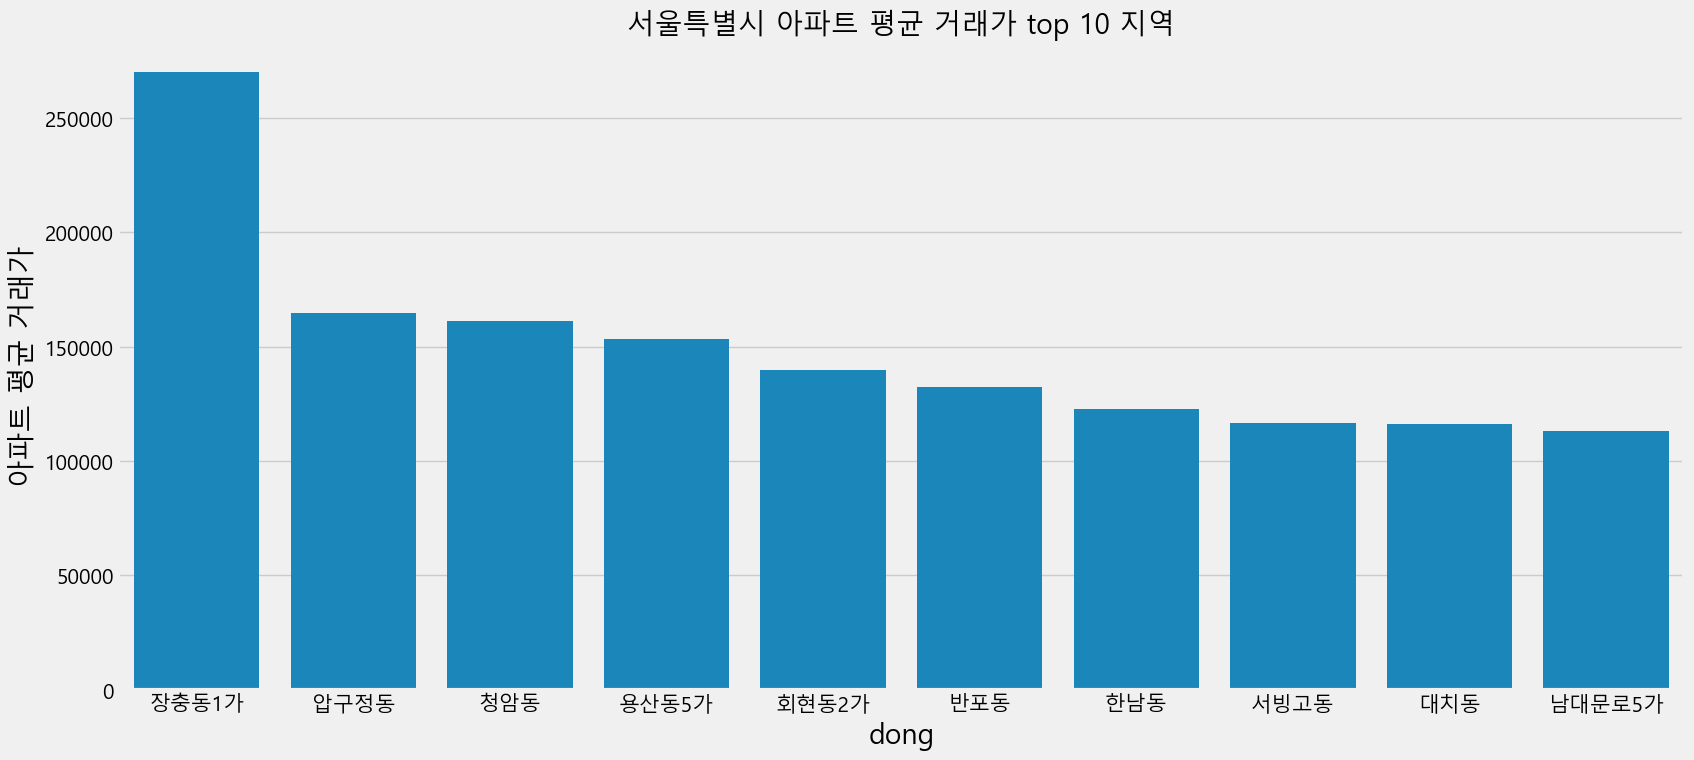

In [38]:
# seaborn 의 barplot을 이용하여 서울특별시 아파트 평균거래가가 높은 10개의 지역을 나타내기

plt.figure(figsize= (18,8))
sns.barplot(x = price_seoul_dong_top_10.index, y = 'transaction_real_price',data= price_seoul_dong_top_10)
plt.title('서울특별시 아파트 평균 거래가 top 10 지역', size = 20)

plt.xticks(size = 15)
plt.yticks(size = 15)

plt.xlabel('dong',size = 20)
plt.ylabel('아파트 평균 거래가', size = 20)

plt.show()


In [39]:
# 부산광역시 데이터만 모아서 출력 
busan_data = train.loc[train['city'] == '부산광역시',:]
busan_data.head(2)

,transaction_id,apartment_id,city,dong,jibun,apt,addr_kr,exclusive_use_area,year_of_completion,transaction_year_month,transaction_date,floor,transaction_real_price,year,month
650921,650921,3310,부산광역시,영주동,160,동아(160-0),영주동 160 동아(160-0),57.09,1998,200801,1~10,4,7900,2008,2008
650922,650922,2939,부산광역시,영주동,587,도경오벨리스,영주동 587 도경오벨리스,84.97,2005,200801,1~10,12,13000,2008,2008


In [40]:
# 부산광역시 지역별로 아파트 평균 거래가 pivot table을 만들기
price_busan_dong = pd.pivot_table(busan_data, index=['dong'], values= 'transaction_real_price',aggfunc = np.mean)
price_busan_dong_top_10 = price_busan_dong.sort_values(['transaction_real_price'],ascending = False)[:10]

price_busan_dong_top_10

,transaction_real_price
dong,
대교동1가,49786.086957
우동,45634.265235
명륜동,38070.565761
충무동1가,35907.074627
남천동,34514.667134
명지동,33570.809676
민락동,33237.740305
중동,31790.139473
장전동,29908.275735


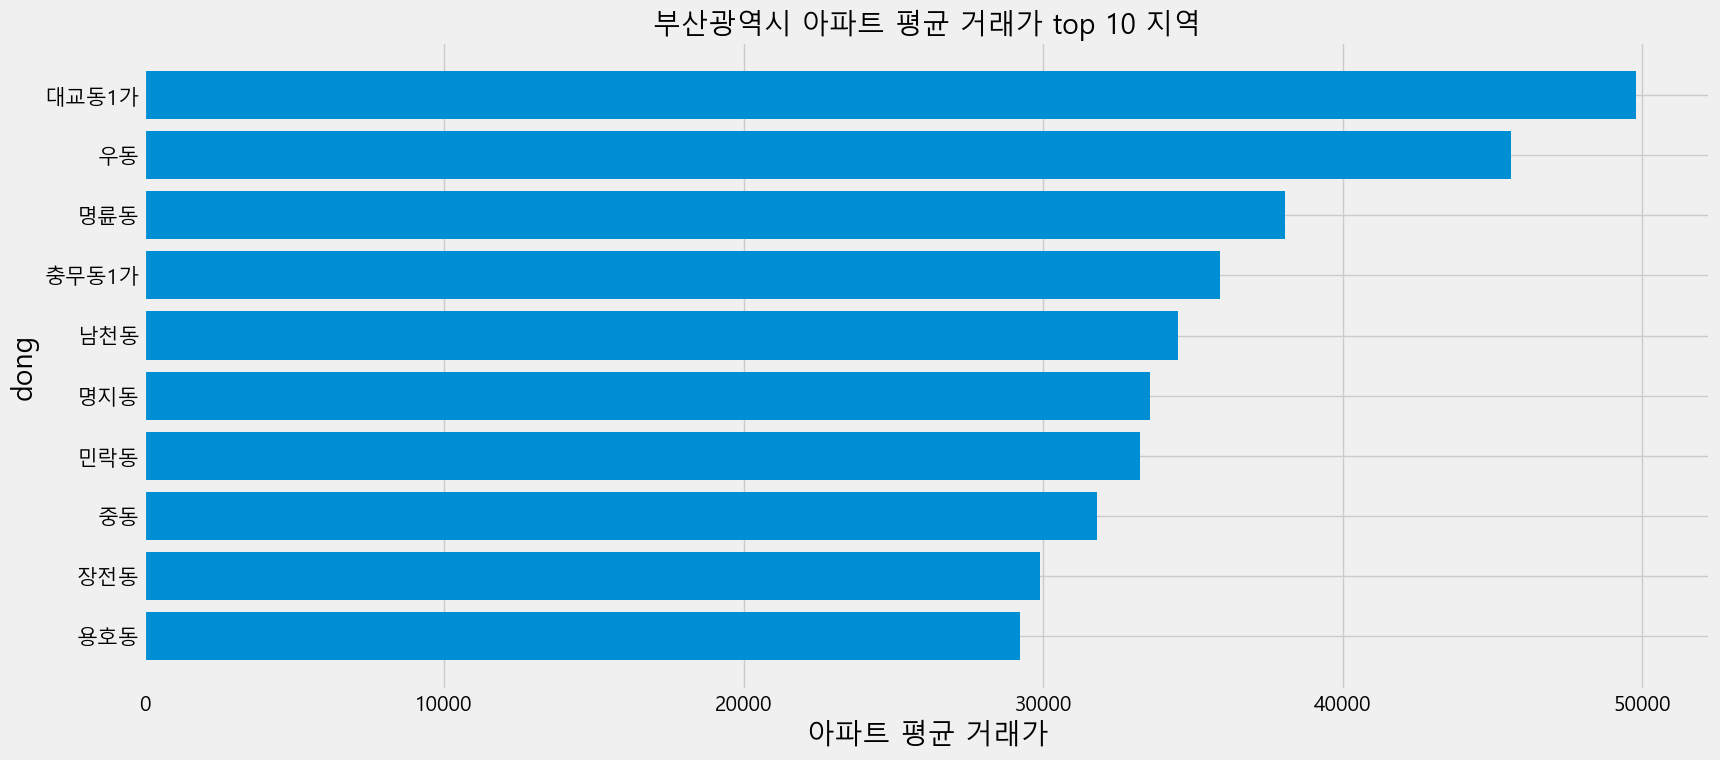

In [41]:
# matplptlib의 barh을 이용하여 부산광역시 아파트 평균거래가가 높은 10개의 지역을 가로로 나타내기

plt.figure(figsize=(18,8))
plt.barh(price_busan_dong_top_10['transaction_real_price'].sort_values().index, price_busan_dong_top_10['transaction_real_price'].sort_values())
plt.title('부산광역시 아파트 평균 거래가 top 10 지역', size = 20)

plt.xticks(size = 15)
plt.yticks(size = 15)

plt.xlabel('아파트 평균 거래가', size = 20)
plt.ylabel('dong', size = 20)
plt.show()

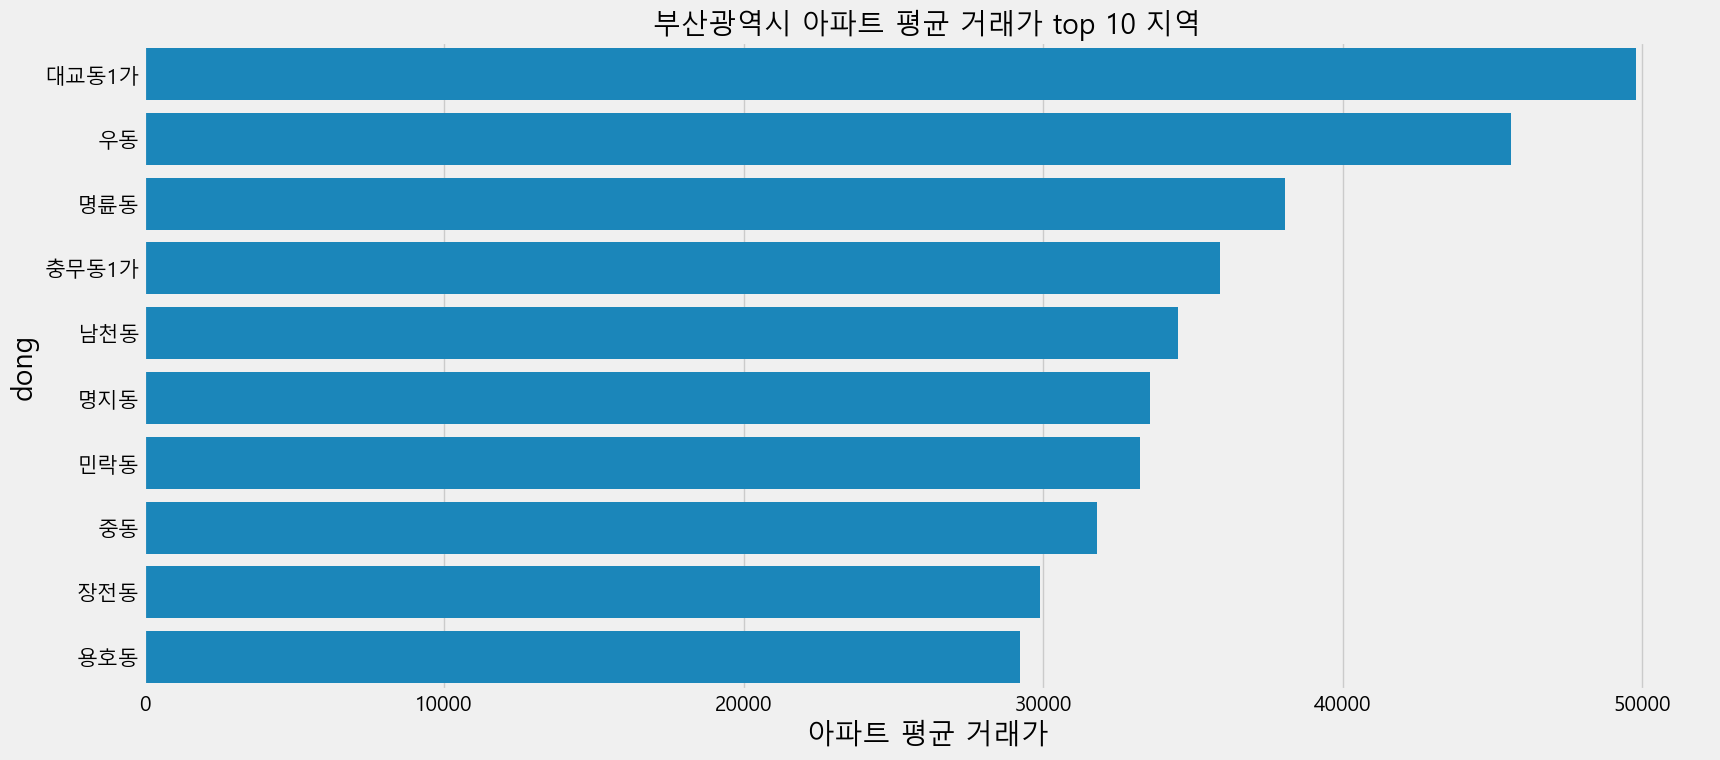

In [42]:
# seaborn 의 barplot 을 이용하여 부산광역시 아파트 평균 거래가가 높은 10개의 지역을 가로로 나타내기

plt.figure(figsize= (18,8))
sns.barplot(x = 'transaction_real_price', y= price_busan_dong_top_10.index, orient='h', data=price_busan_dong_top_10)
plt.title('부산광역시 아파트 평균 거래가 top 10 지역', size = 20)

plt.xticks(size = 15)
plt.yticks(size = 15)

plt.xlabel('아파트 평균 거래가', size= 20)
plt.ylabel('dong',size = 20)
plt.show()

In [43]:
train.loc[train['dong'] == '장충동1가','apt'].unique()

array(['장충동라임카운티', '상지리츠빌장충동카일룸', '장충레지던스'], dtype=object)

In [44]:
train.loc[train['dong']=='대교동1가', 'apt'].unique()

array(['원광브릿지타워'], dtype=object)

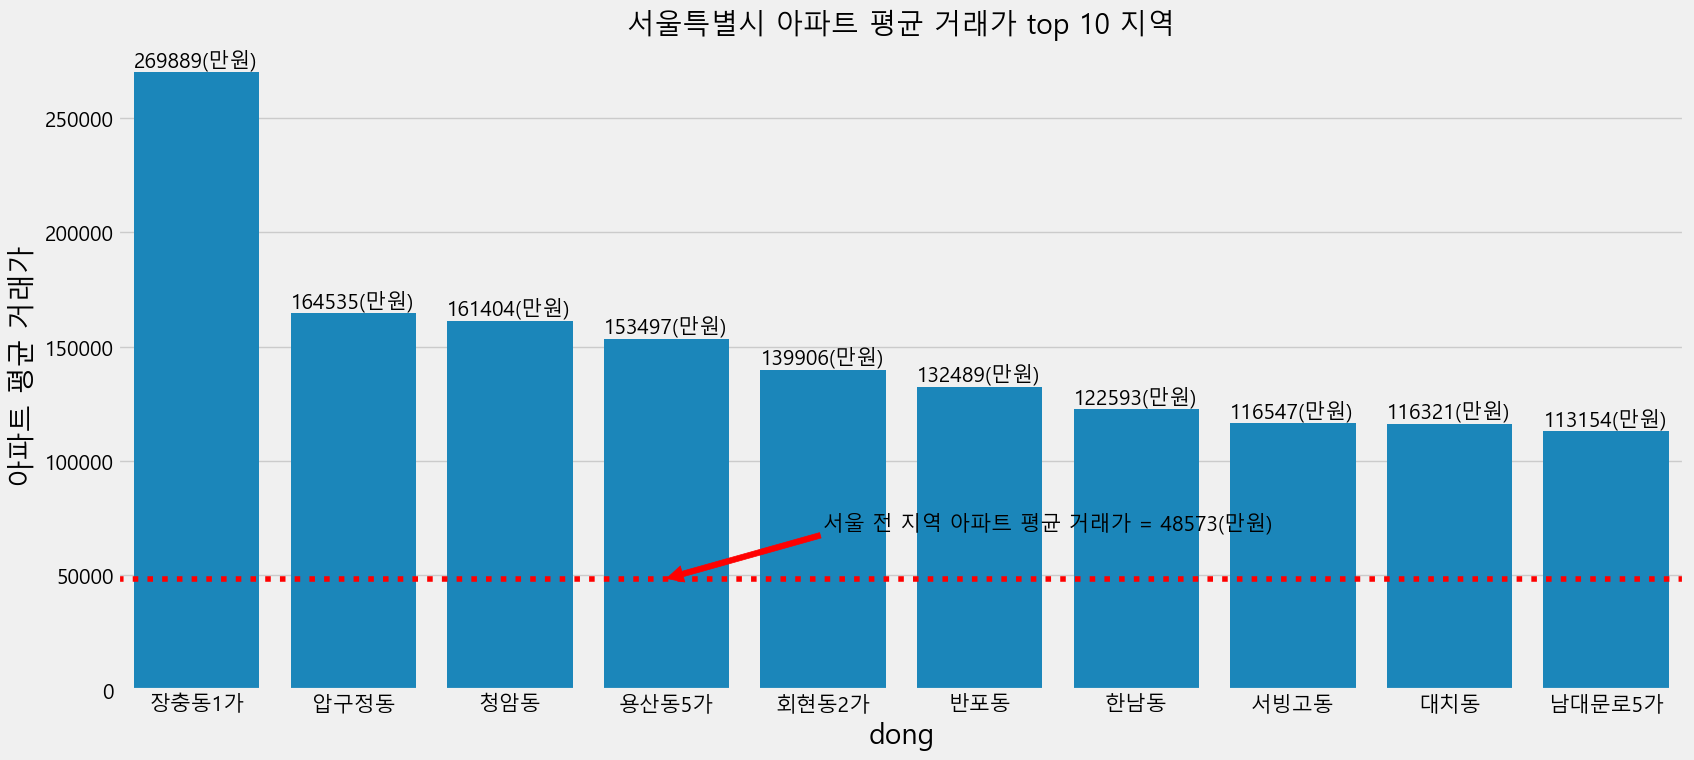

In [45]:
plt.figure(figsize=(18,8))
sns.barplot(x = price_seoul_dong_top_10.index, y = 'transaction_real_price', data = price_seoul_dong_top_10)
plt.title('서울특별시 아파트 평균 거래가 top 10 지역', size = 20)

plt.xticks(size = 15)
plt.yticks(size = 15)

plt.xlabel('dong',size = 20)
plt.ylabel('아파트 평균 거래가', size = 20)

plt.axhline(48573, color = 'red', linestyle=':')
plt.annotate('서울 전 지역 아파트 평균 거래가 = 48573(만원)', xy = (3,48573), xytext=(4,70000), arrowprops={'color':'red'},size = 15)

for i in range(len(price_seoul_dong_top_10)):
    plt.text(x = range(len(price_seoul_dong_top_10))[i]-0.4, y = price_seoul_dong_top_10['transaction_real_price'][i]+2500,s = str(round(price_seoul_dong_top_10['transaction_real_price'][i]))+ '(만원)',size=15)

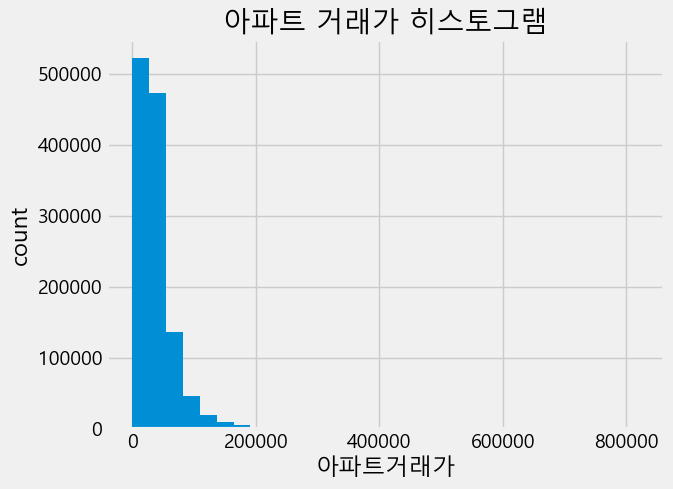

In [46]:
# matplotlib 히스토그램
plt.hist(train['transaction_real_price'], bins = 30)
plt.title('아파트 거래가 히스토그램', size = 20)

plt.xlabel('아파트거래가')
plt.ylabel('count')
plt.show()

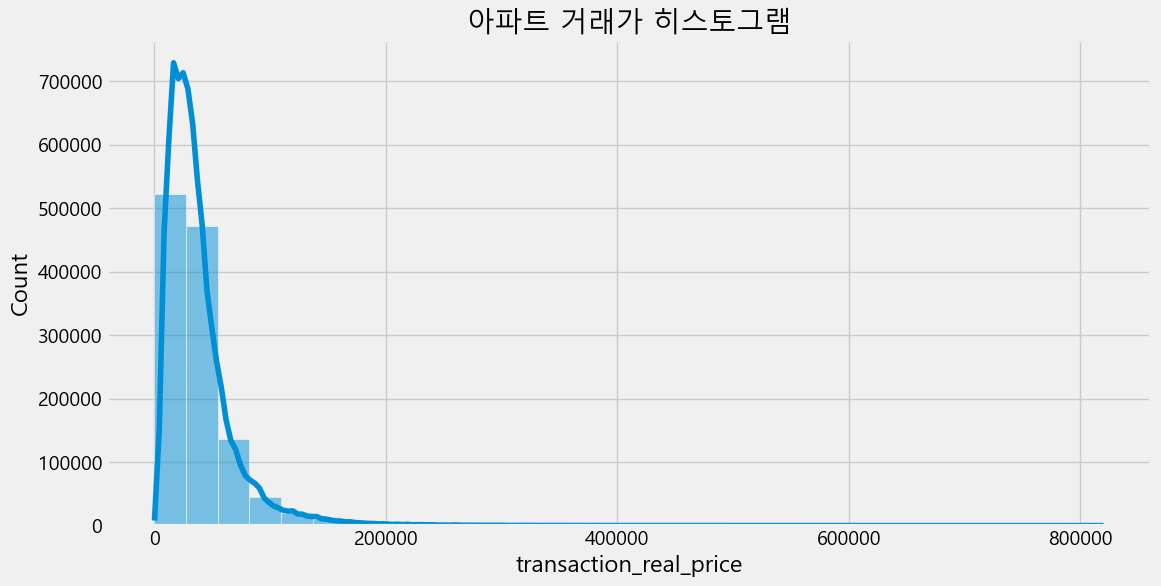

In [47]:
# seaborn 히스토그램

plt.figure(figsize=(12,6))
sns.histplot(x = 'transaction_real_price', data = train, kde = True, bins = 30)
plt.title('아파트 거래가 히스토그램', size =20)

plt.show()

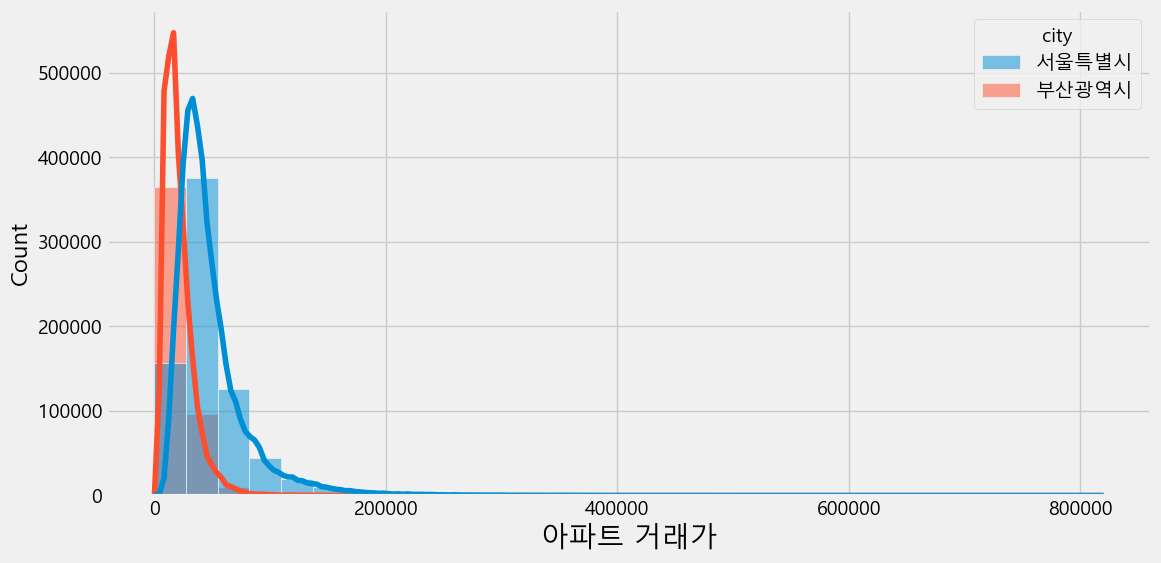

In [48]:
# 이변량 히스토그램
# matplotlib 히스토그램

plt.figure(figsize=(12,6))
sns.histplot(x= 'transaction_real_price', data = train, kde = True, hue= 'city', bins = 30)
plt.xlabel('아파트 거래가', size = 20)
plt.show()


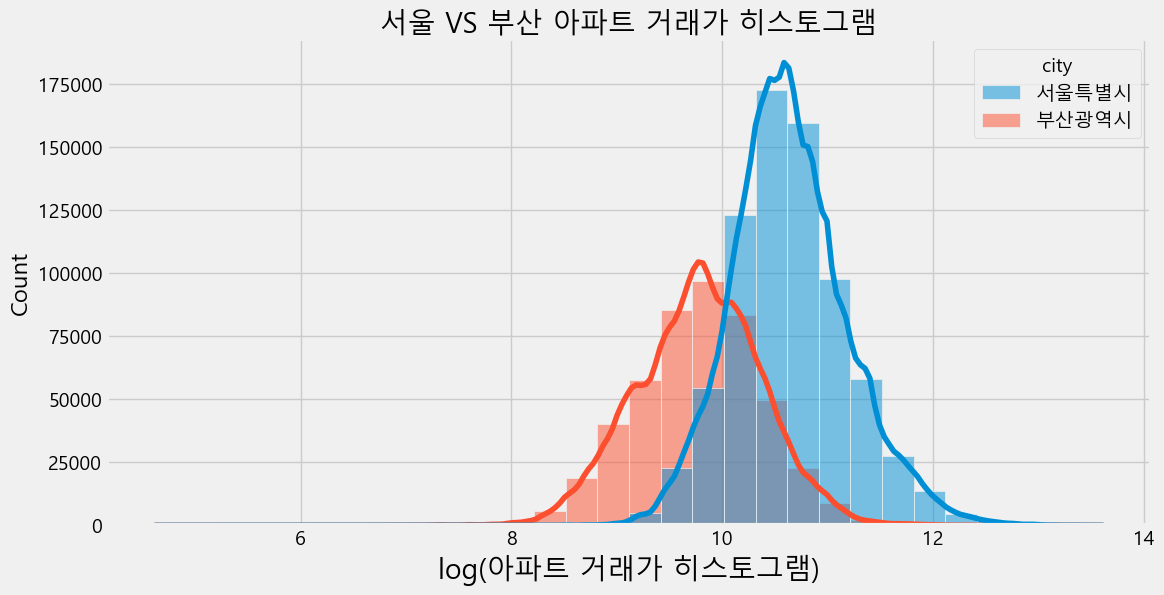

In [49]:
# 명확한 차이 확인을 위해 로그를 취해 비교

plt.figure(figsize=(12, 6))
sns.histplot(x= np.log1p(train['transaction_real_price']), data=train, kde=True,hue='city', bins = 30)
plt.title('서울 VS 부산 아파트 거래가 히스토그램', size = 20)

plt.xlabel('log(아파트 거래가 히스토그램)', size = 20)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

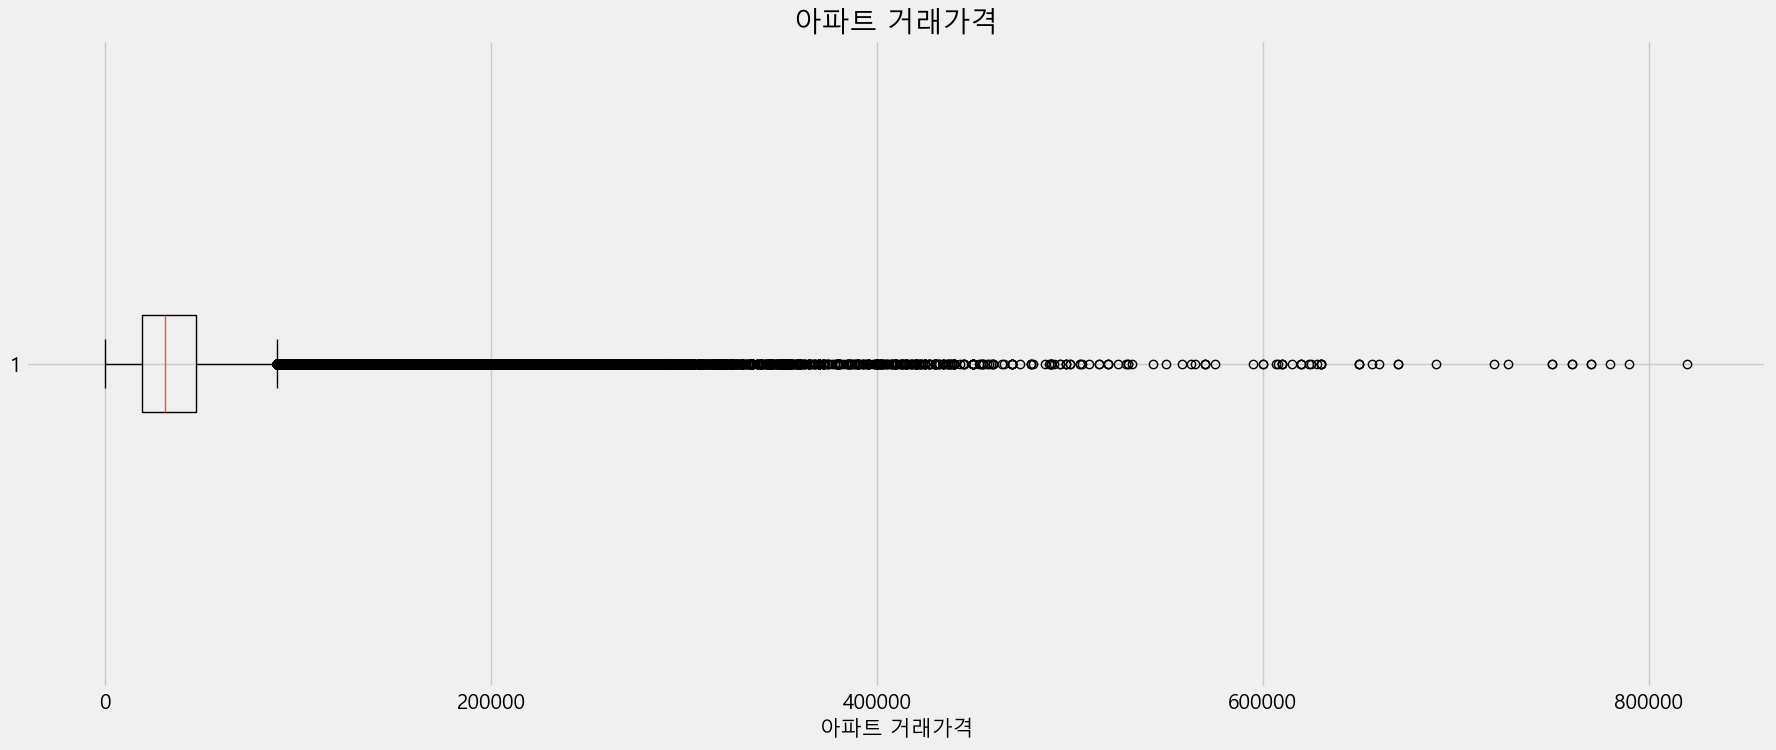

In [50]:
# 일변량 boxplot

# plt의 boxplot 을 통해 아파트 거래가의 이상치를 확인
plt.figure(figsize= (20,8))
plt.boxplot(train['transaction_real_price'], vert= False)
plt.title('아파트 거래가격', size = 20)
plt.xticks(size = 15)
plt.yticks(size = 15)
plt.xlabel('아파트 거래가격', size = 15)
plt.show

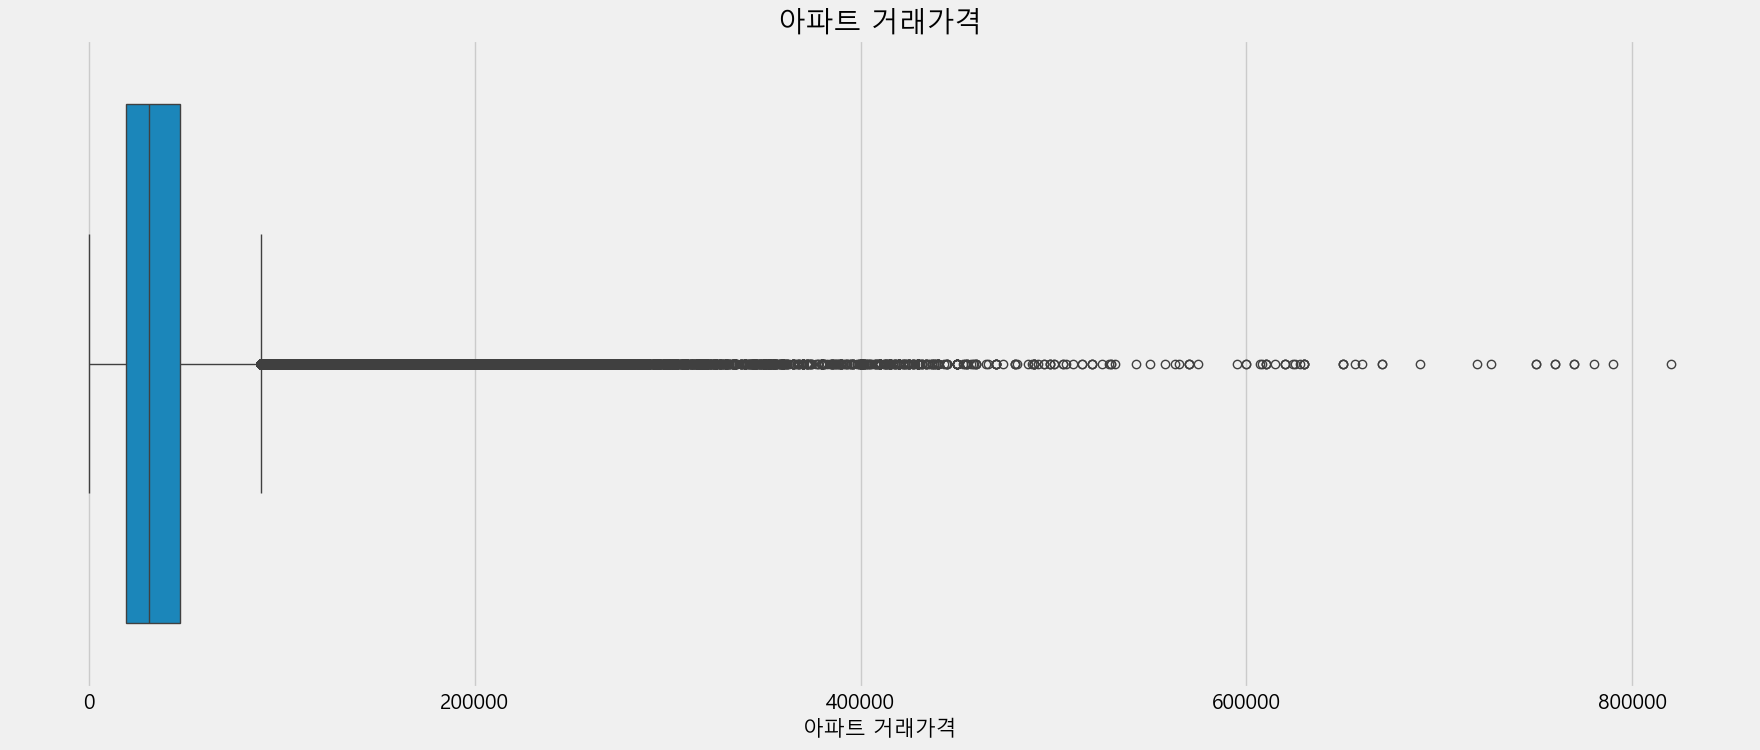

In [51]:
# seaborn 의 boxplot (거래가 이상치 확인)
plt.figure(figsize = (20, 8))
sns.boxplot(x = 'transaction_real_price', data = train)
plt.title('아파트 거래가격', size = 20)
plt.xticks(size= 15)
plt.yticks(size = 15)
plt.xlabel('아파트 거래가격', size = 15)
plt.show()

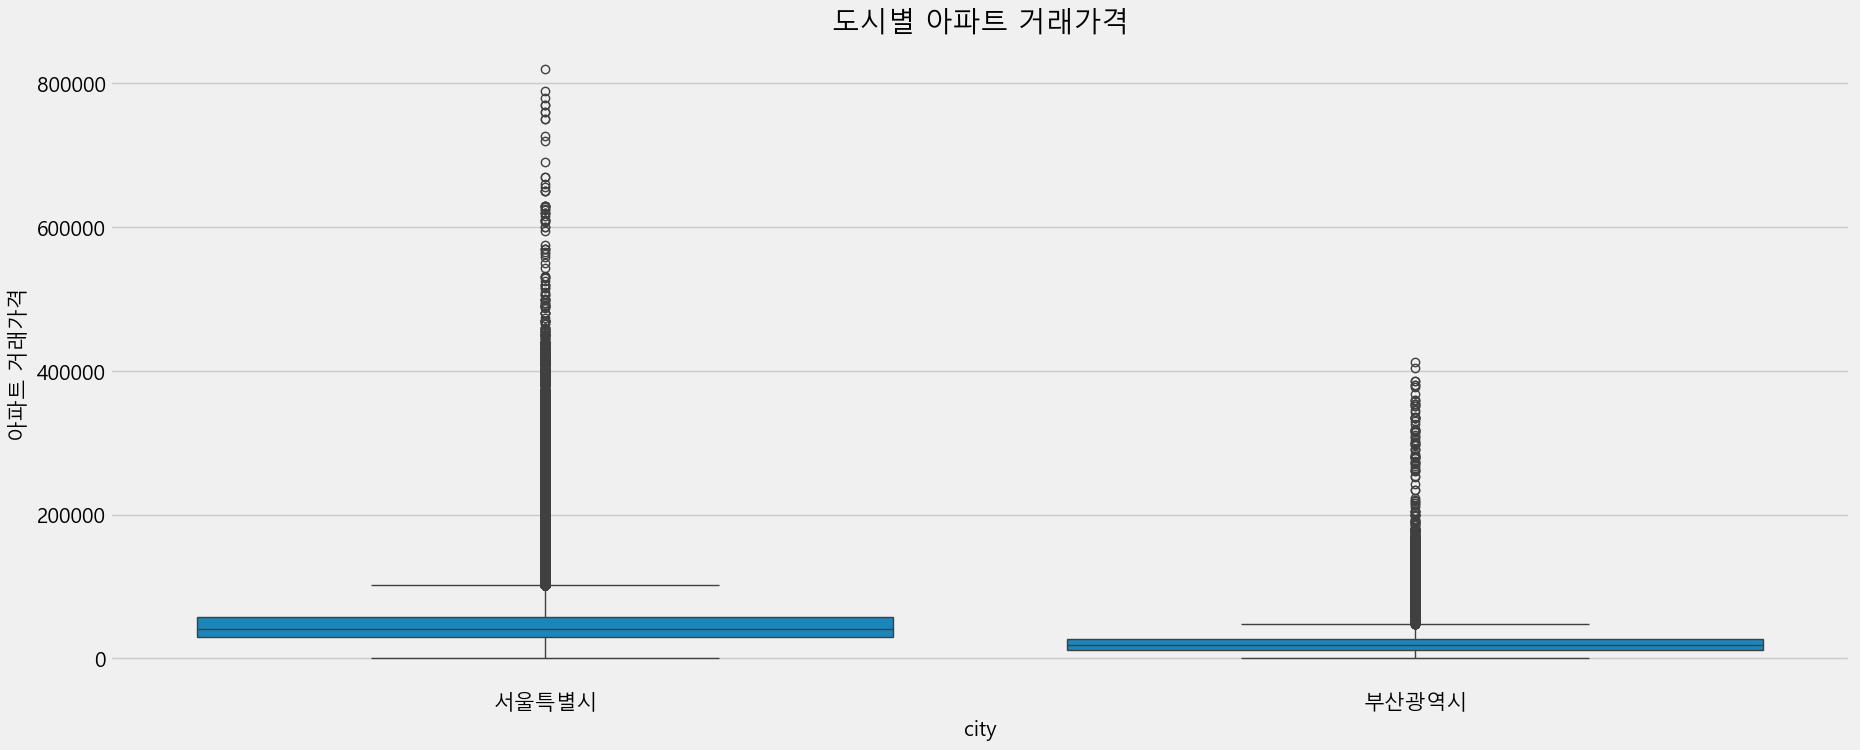

In [52]:
# seaborn 의 boxplot(도시별 거래가)

plt.figure(figsize= (20, 8))
sns.boxplot(x= 'city', y= 'transaction_real_price', data=train)
plt.title('도시별 아파트 거래가격', size = 20)

plt.xticks(size = 15)
plt.yticks(size =15)

plt.xlabel('city', size = 15)
plt.ylabel('아파트 거래가격', size = 15)
plt.show()

In [53]:
# +1 : 완벽한 양의 선형 상관관계
# -1 : 완벽한 음의 선형 상관관계
# 0 : 선형 상관관계 없음

# 상관관계 값을 cor 이라는 객체에 할당


# cor = train.corr()
# cor


# 숫자 컬럼만 자동으로 뽑아 상관관계를 계산 
cor = train.select_dtypes(include='number').corr()
cor

,transaction_id,apartment_id,exclusive_use_area,year_of_completion,transaction_year_month,floor,transaction_real_price,year,month
transaction_id,1.000000,-0.050520,0.039815,0.011021,0.205657,0.061906,-0.120734,0.205642,0.205642
apartment_id,-0.050520,1.000000,0.015098,-0.042868,-0.002918,-0.011769,0.017576,-0.002870,-0.002870
exclusive_use_area,0.039815,0.015098,1.000000,0.168540,0.019041,0.134716,0.561563,0.018788,0.018788
year_of_completion,0.011021,-0.042868,0.168540,1.000000,0.092881,0.243510,0.052656,0.092627,0.092627
transaction_year_month,0.205657,-0.002918,0.019041,0.092881,1.000000,0.013425,0.183910,0.999936,0.999936
floor,0.061906,-0.011769,0.134716,0.243510,0.013425,1.000000,0.112278,0.013288,0.013288
transaction_real_price,-0.120734,0.017576,0.561563,0.052656,0.183910,0.112278,1.000000,0.183714,0.183714
year,0.205642,-0.002870,0.018788,0.092627,0.999936,0.013288,0.183714,1.000000,1.000000
month,0.205642,-0.002870,0.018788,0.092627,0.999936,0.013288,0.183714,1.000000,1.000000


In [54]:
# 확인해보니 문자열(obj 타입) 컬럼 때문에 상관관계 (숫자가 아님) 계산이 불가함 .오류  
train.select_dtypes(exclude="number").columns

Index(['city', 'dong', 'jibun', 'apt', 'addr_kr', 'transaction_date'], dtype='object')

sns.heatmap(색을 입힐 데이터, cmap = 색깔)
annot = True : heatmap 안에 상관계수 값을 표시
fmt = ".3f" : 소수점 3번째 자리까지 표시
cbar = False: colorbar 를 보이지 않게  함
linewidths = 0.5 : 칸 마다 라인의 두께를 0.5로 설정

In [55]:
# 컬러맵 찾기
import matplotlib.pyplot as plt

plt.colormaps()

['magma',
 'inferno',
 'plasma',
 'viridis',
 'cividis',
 'twilight',
 'twilight_shifted',
 'turbo',
 'berlin',
 'managua',
 'vanimo',
 'Blues',
 'BrBG',
 'BuGn',
 'BuPu',
 'CMRmap',
 'GnBu',
 'Greens',
 'Greys',
 'OrRd',
 'Oranges',
 'PRGn',
 'PiYG',
 'PuBu',
 'PuBuGn',
 'PuOr',
 'PuRd',
 'Purples',
 'RdBu',
 'RdGy',
 'RdPu',
 'RdYlBu',
 'RdYlGn',
 'Reds',
 'Spectral',
 'Wistia',
 'YlGn',
 'YlGnBu',
 'YlOrBr',
 'YlOrRd',
 'afmhot',
 'autumn',
 'binary',
 'bone',
 'brg',
 'bwr',
 'cool',
 'coolwarm',
 'copper',
 'cubehelix',
 'flag',
 'gist_earth',
 'gist_gray',
 'gist_heat',
 'gist_ncar',
 'gist_rainbow',
 'gist_stern',
 'gist_yarg',
 'gnuplot',
 'gnuplot2',
 'gray',
 'hot',
 'hsv',
 'jet',
 'nipy_spectral',
 'ocean',
 'pink',
 'prism',
 'rainbow',
 'seismic',
 'spring',
 'summer',
 'terrain',
 'winter',
 'Accent',
 'Dark2',
 'Paired',
 'Pastel1',
 'Pastel2',
 'Set1',
 'Set2',
 'Set3',
 'tab10',
 'tab20',
 'tab20b',
 'tab20c',
 'grey',
 'gist_grey',
 'gist_yerg',
 'Grays',
 'magma_r',

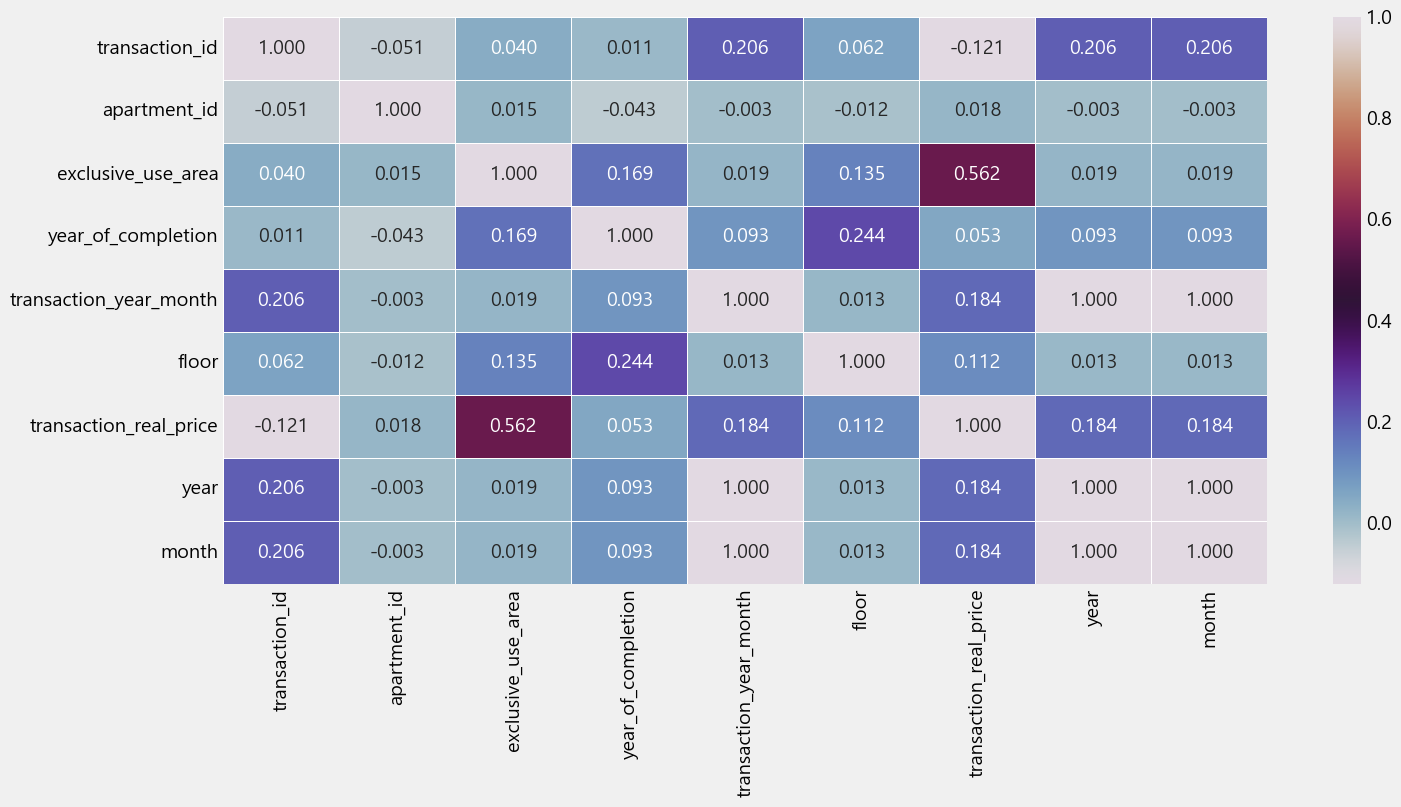

In [56]:
# heatmap 을 사용해 상관관계 테이블을 한눈에 보기 쉬운 형태로 만들기
plt.figure(figsize=(15, 7))
sns.heatmap(cor, cmap = "twilight", annot = True, linewidths= 0.5, fmt = ".3f", cbar = True)
plt.show()

In [57]:
# 불필요한 컬럼을 지우기 위해 , 공백 여부 , 오타 확인 을 위해 컬럼명들 확인 
train.columns.tolist()

['transaction_id',
 'apartment_id',
 'city',
 'dong',
 'jibun',
 'apt',
 'addr_kr',
 'exclusive_use_area',
 'year_of_completion',
 'transaction_year_month',
 'transaction_date',
 'floor',
 'transaction_real_price',
 'year',
 'month']

이미 그래프를 그려서 컬럼 을 drop 시켰지만, 반영이 안됨.
이런 경우 반드시 corr 다시 계산해야 함 .
1. 컬럼제거 > 2. 숫자 컬럼만 선택 > 3. heatmap 다시 그림 



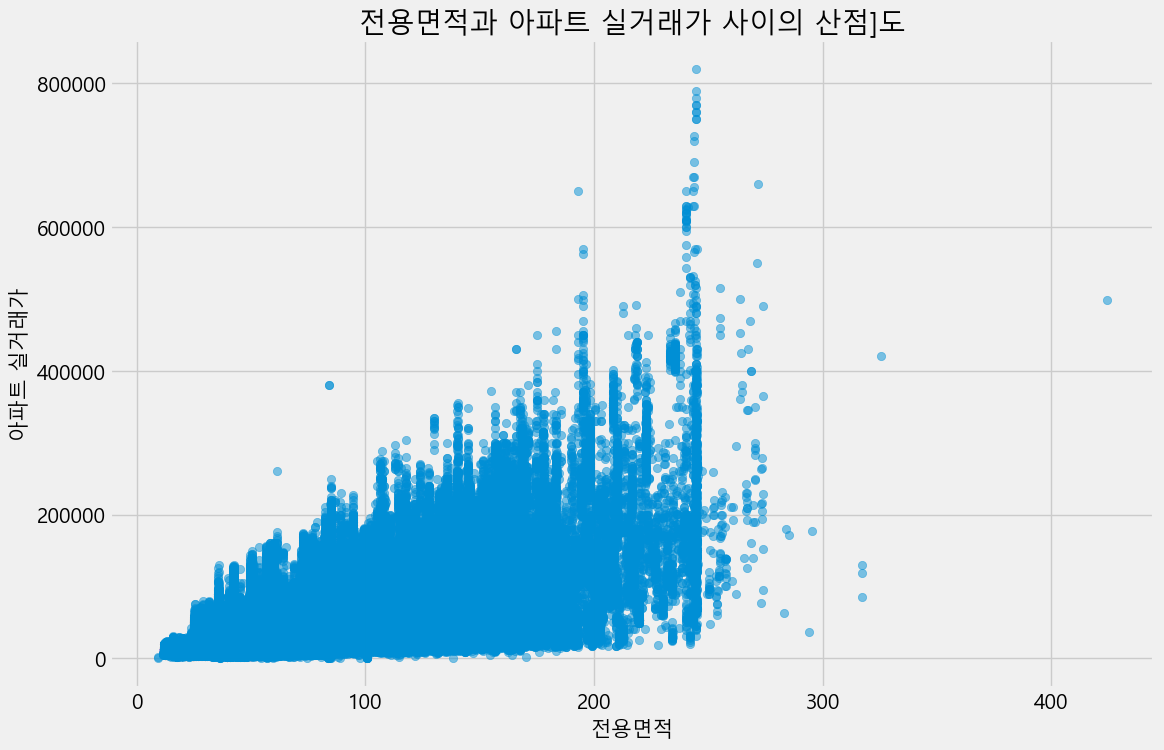

In [58]:
# matplotlib 을 이용해서 전용면적과 아파트 실거래가의 산점도를 표현
plt.figure(figsize=(12,8))
plt.scatter(x = train['exclusive_use_area'], y= train ['transaction_real_price'], alpha = 0.5)
plt.title('전용면적과 아파트 실거래가 사이의 산점]도', size = 20)

plt.xticks(size= 15)
plt.yticks(size = 15)

plt.xlabel('전용면적', size = 15)
plt.ylabel('아파트 실거래가', size= 15)

plt.show()

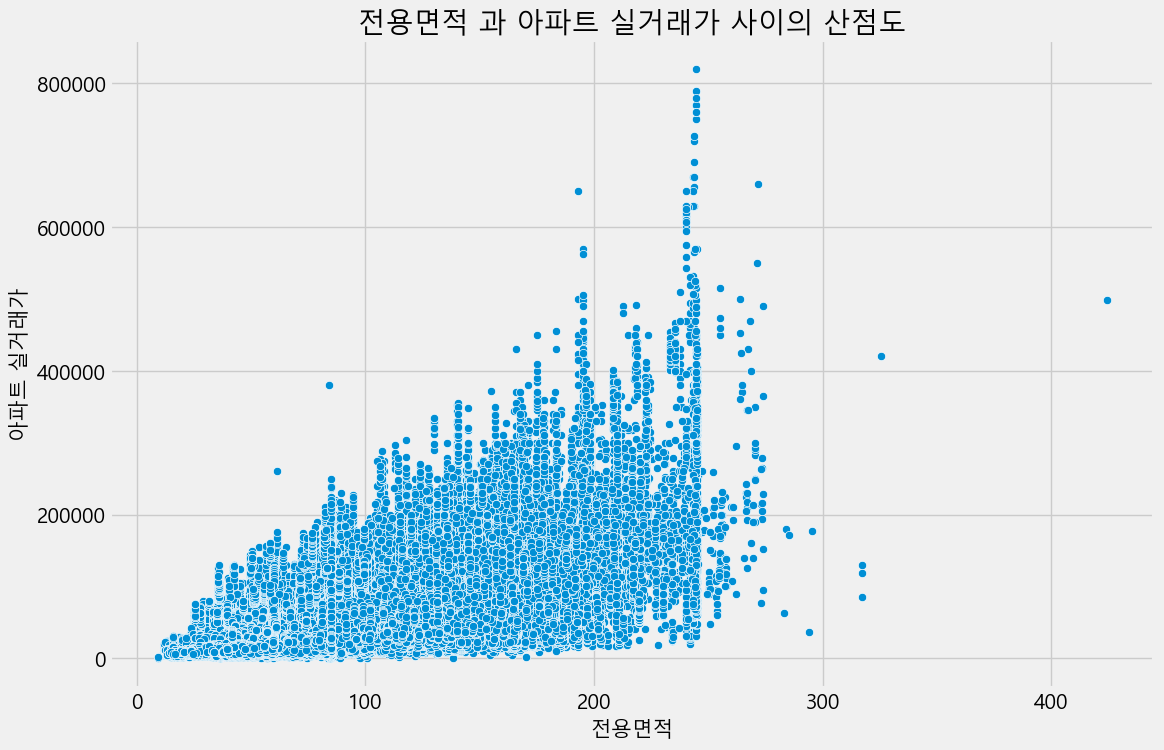

In [59]:
# seaborn를 이용해서 전용면적과 아파트 실거래가의 산점도를 표현
plt.figure(figsize=(12,8))
sns.scatterplot(x= 'exclusive_use_area', y= 'transaction_real_price', data = train)
plt.title('전용면적 과 아파트 실거래가 사이의 산점도',size = 20)

plt.xticks(size = 15)
plt.yticks(size = 15)

plt.xlabel('전용면적', size = 15)
plt.ylabel('아파트 실거래가', size = 15)

plt.show()

<Figure size 1200x800 with 0 Axes>

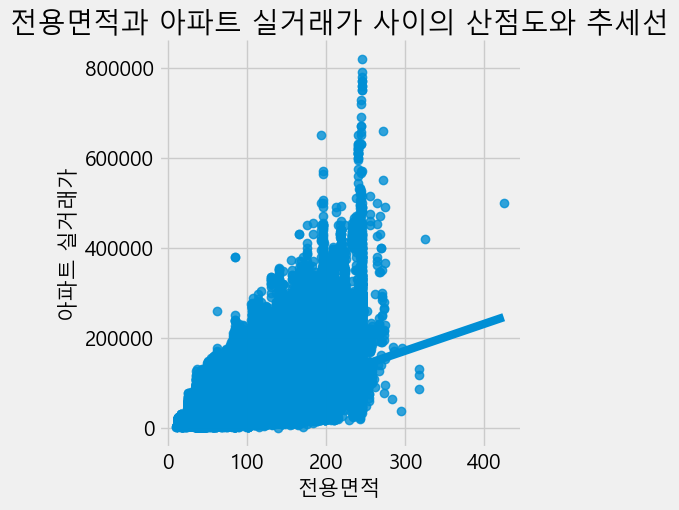

In [60]:
# seaborn 의 implot를 이용해서 전용면적과 아파트 실거래가의 산점도와 추세선을 표현

plt.figure(figsize=(12, 8))

sns.lmplot(x= 'exclusive_use_area', y= 'transaction_real_price', data = train)
plt.title('전용면적과 아파트 실거래가 사이의 산점도와 추세선', size = 20)

plt.xticks(size =15)
plt.yticks(size = 15)

plt.xlabel('전용면적', size = 15)
plt.ylabel('아파트 실거래가', size = 15)
plt.show()

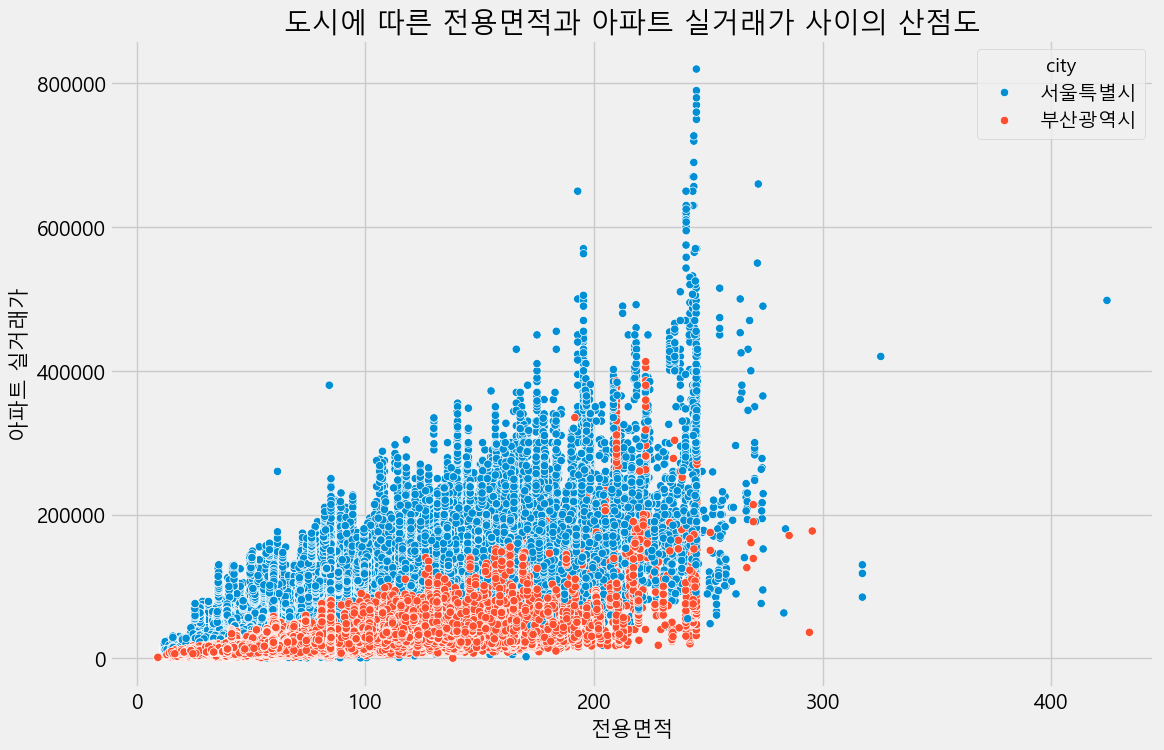

In [61]:
# 이변량 scatter plot 
# seaborn 를 이용해서  도시별 전용면적과 아파트 실거래가의 산점도를 표현

plt.figure(figsize = (12, 8))
sns.scatterplot(x = 'exclusive_use_area', y= 'transaction_real_price', hue = 'city', data = train)
plt.title('도시에 따른 전용면적과 아파트 실거래가 사이의 산점도', size = 20)

plt.xticks(size = 15)
plt.yticks(size = 15)

plt.xlabel('전용면적', size = 15)
plt.ylabel('아파트 실거래가', size = 15)
plt.show()

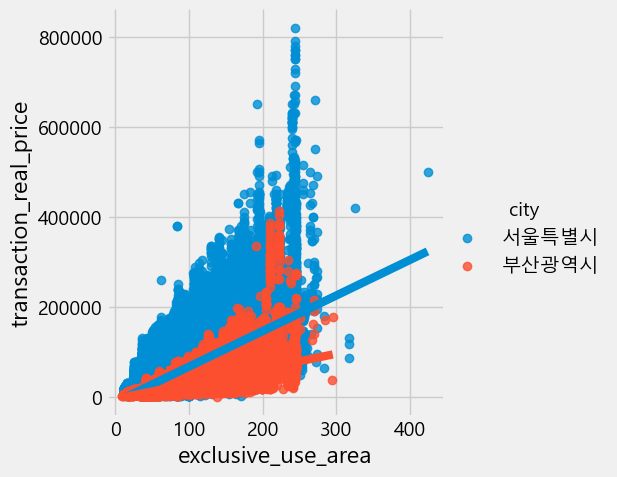

In [62]:
sns.lmplot(x= 'exclusive_use_area', y= 'transaction_real_price', hue ='city', data = train)
plt.show()

In [63]:
# 전용면적당 아파트 거래가 변수를 만들기
train['price_per_area'] = train['transaction_real_price'] / train['exclusive_use_area']

price_per_area_by_year = train.groupby(['year'])[['price_per_area']].mean()
price_per_area_by_year

,price_per_area
year,
2008,371.986343
2009,443.344932
2010,387.150633
2011,438.326002
2012,443.270052
2013,449.025207
2014,466.183631
2015,505.157006
2016,559.931274


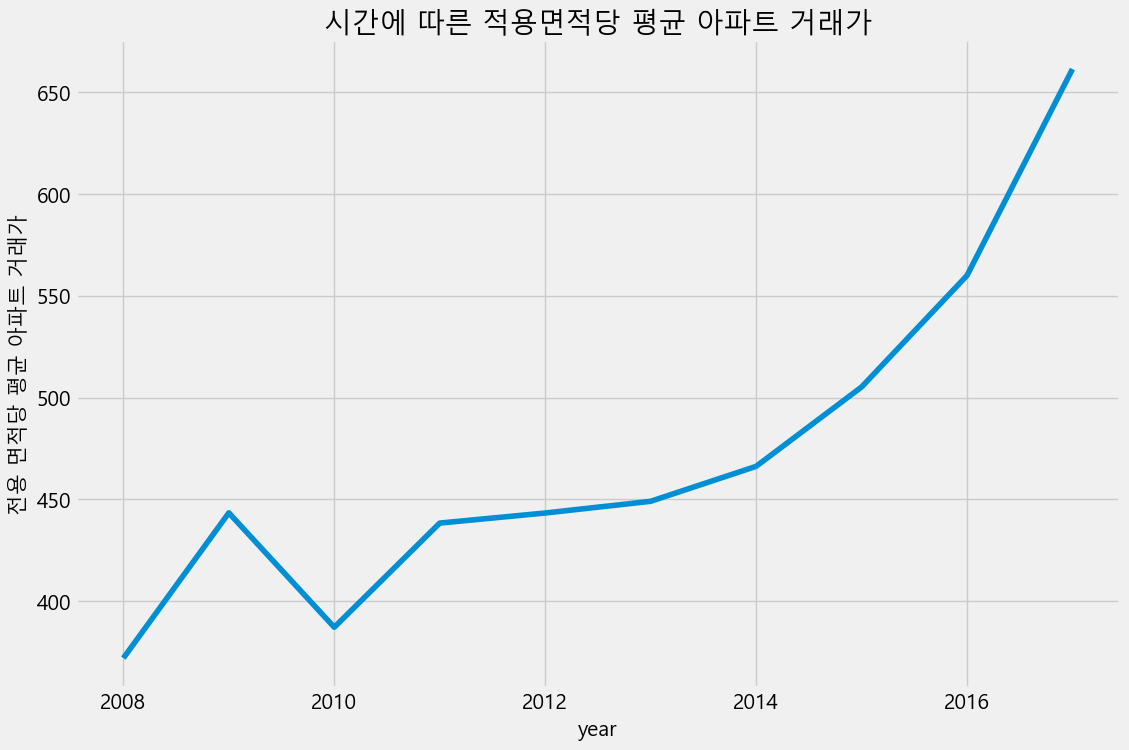

In [64]:
# matplotlib 의 line plot 을 이용해서 전용면적당 평균 아파트 거래가의 추이를 시각화

plt.figure(figsize=(12,8))
plt.plot(price_per_area_by_year.index, price_per_area_by_year['price_per_area'])
plt.title('시간에 따른 적용면적당 평균 아파트 거래가', size= 20)

plt.xticks(size = 15)
plt.yticks(size = 15)


plt.xlabel('year',size = 15)
plt.ylabel('전용 면적당 평균 아파트 거래가', size = 15)
plt.show()

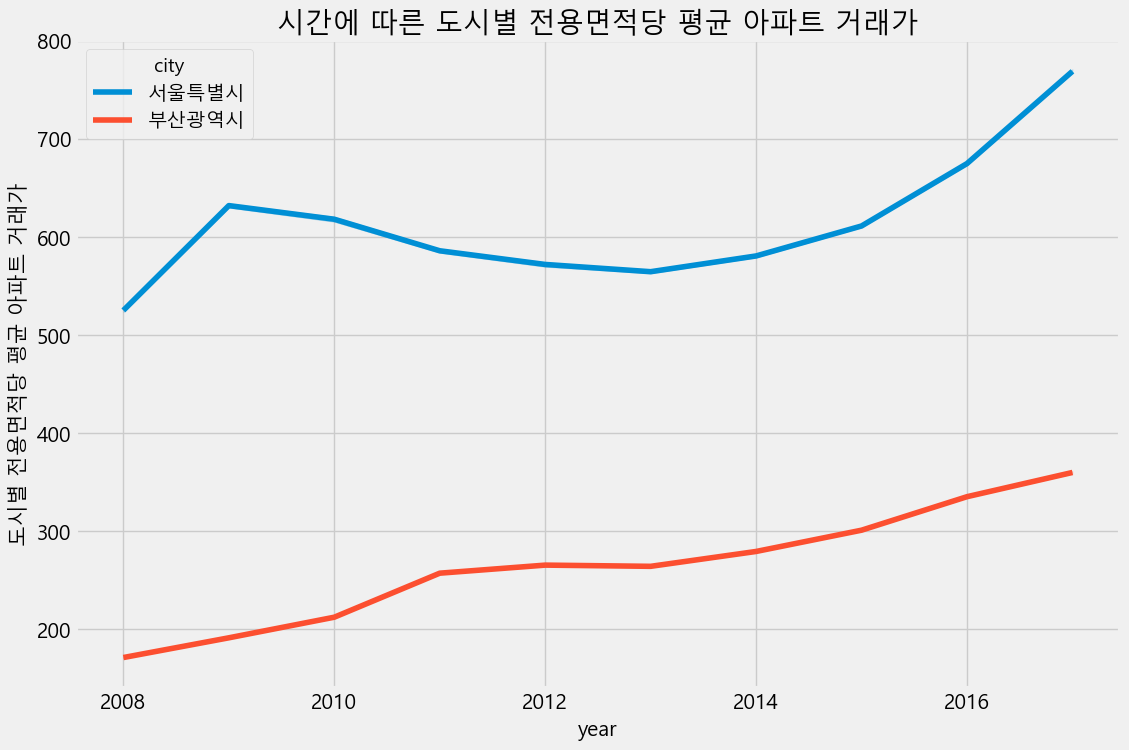

In [65]:
# seaborn을 이용해서 도시별 전용면적당 평균 아파트 거래가 line plot 를 그리기

plt.figure(figsize=(12,8))
sns.lineplot(x = 'year', y= 'price_per_area', hue = 'city', data = train)
plt.title('시간에 따른 도시별 전용면적당 평균 아파트 거래가', size = 20)

plt.xticks(size = 15)
plt.yticks(size = 15)

plt.xlabel('year', size = 15)
plt.ylabel('도시별 전용면적당 평균 아파트 거래가', size = 15)
plt.show()

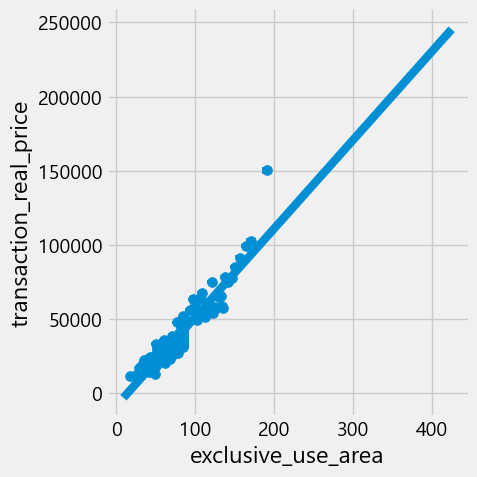

In [66]:
# 평단가

sns.lmplot(data = train, x= 'exclusive_use_area', y = 'transaction_real_price', x_bins = 200)


In [67]:
train.iloc[[5732,566959],:]

# 평당 아파트 실거래가 파생변수를 생성
train['price_per_area']= train['transaction_real_price'] / train['exclusive_use_area']*3.3


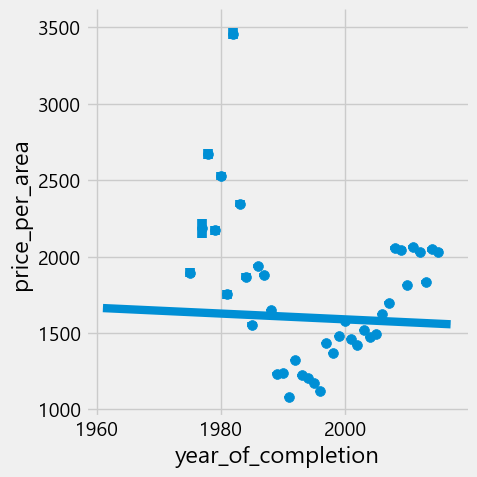

In [68]:
# 아파트 연식
# 설립연도

sns.lmplot(data = train, x = 'year_of_completion', y= 'price_per_area', x_bins = 150)


In [69]:
# 아파트 연식 변수를 생성

train['year'] = train['transaction_year_month'].astype(str).str[:4].astype(int)
train['month']=  train['transaction_year_month'].astype(str).str[4:].astype(int)

train['age'] = train['year'] - train['year_of_completion']

train.loc[(train['transaction_date']== '21~30') | (train['transaction_date'] == '21~28')| (train['transaction_date'] == '21~29'), 'transaction_date'] = '21~31'

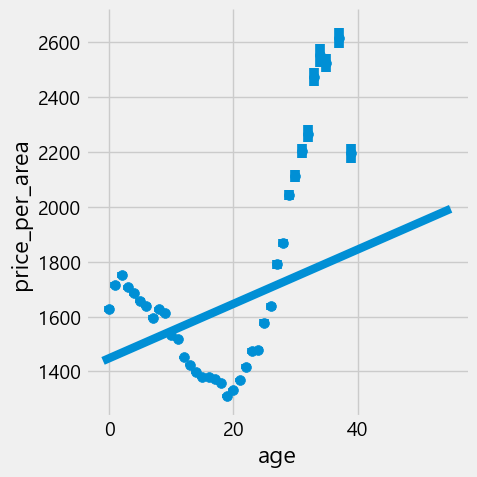

In [70]:
sns.lmplot(data = train, x = 'age', y= 'price_per_area', x_bins=150)

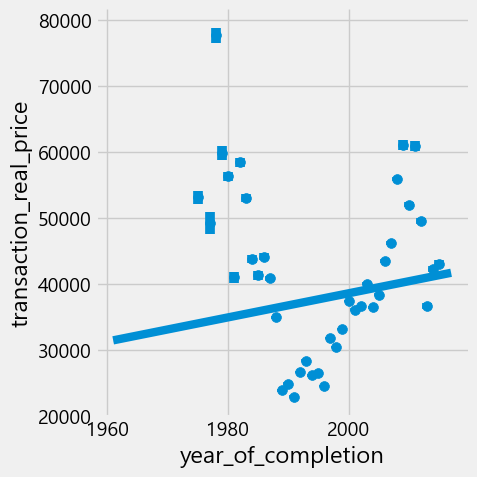

In [71]:
sns.lmplot(data = train, x= 'year_of_completion', y= 'transaction_real_price',x_bins = 150)


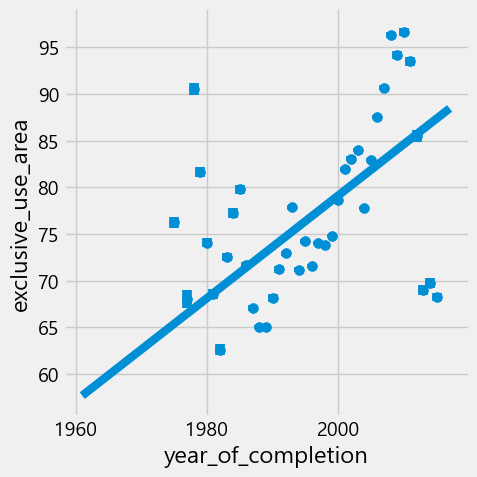

In [72]:
sns.lmplot(data = train, x= 'year_of_completion', y= 'exclusive_use_area', x_bins = 150)

In [73]:
train.loc[train['age']< 20, 'reconstruction'] = 'NO'
train.loc[train['age']>=20 , 'reconstruction'] = 'YES'

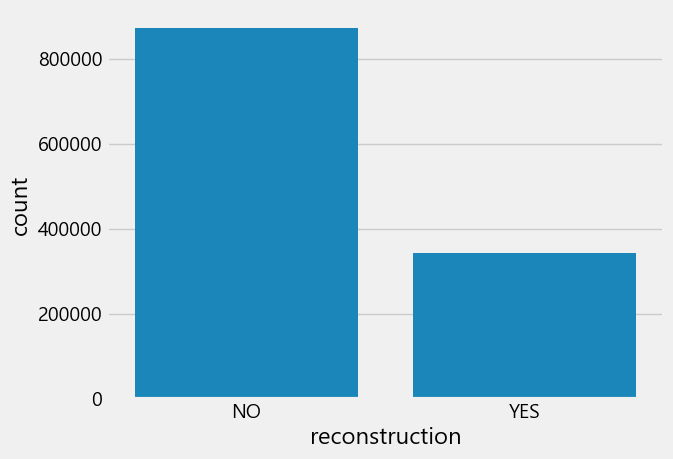

In [74]:
sns.countplot(x = 'reconstruction', data = train)
plt.show()

In [75]:
train['apt'].unique()

array(['신현(101동)', '사직파크맨션', '두레엘리시안', ..., '삼협 아띠랑스', '(94-8)',
       '동부산관광단지 삼정그린코아 더베스트'], shape=(10440,), dtype=object)

In [76]:
pip install tqdm

In [77]:
# 1  분류범주 축소
# re 모듈을 선언하고 괄호와 괄호안 문자르 찾아 삭제
from tqdm import tqdm
import time
import re

regex = "\(.*\)"

for i in tqdm(range(len(train))):
    train.at[i, 'apt'] = re.sub(regex, "", train.at[i, 'apt'])

100%|██████████| 1216553/1216553 [00:30<00:00, 39389.05it/s]


In [78]:
train['apt'].unique()

array(['신현', '사직파크맨션', '두레엘리시안', ..., '모드니 하이츠', '삼협 아띠랑스',
       '동부산관광단지 삼정그린코아 더베스트'], shape=(9375,), dtype=object)

In [79]:
# 2 . 범주범위 선택
train['apt'].value_counts()[:20]

apt
현대        17716
한신        10135
삼성         6771
대우         6390
신동아        6386
두산         5801
우성         5781
주공2        5669
삼성래미안      5483
벽산         4651
대림         4582
동원로얄듀크     4430
경남         4030
삼환         3896
극동         3771
삼익         3583
롯데캐슬       3570
쌍용         3409
코오롱        3320
한양         3231
Name: count, dtype: int64

In [80]:
# 상위 20개 아파트 이름 리스트를 생성
apt_brand_list = train['apt'].value_counts()[:20].index

# 상위 20개 아파트 이름에 속하는지 구별하는 변수 생성
train['branded'] = False

# 아파트 이름이 리스트 안의 브랜드를 가지고 있다면
# 대표 이름으로 바뀌고 branded 변수를 true로 바꿈
for brand in tqdm(apt_brand_list):
    train['apt'].loc[train['apt'].str.contains(brand)] = brand
    train['branded'].loc[train['apt'].str.contains(brand)] = True

# branded 변수가 False인 아파트를 others라는 이름으로 통합
train['apt'].loc[~train['branded']] = 'others'    

# test 데이터도 동일하게 처리
test['branded'] = False

for brand in tqdm(apt_brand_list):
    test['apt'].loc[test['apt'].str.contains(brand)] = brand
    test['branded'].loc[test['apt'].str.contains(brand)] = True

test['apt'].loc[~test['branded']] = 'others'

  0%|          | 0/20 [00:00<?, ?it/s]C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_34256\108733945.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['apt'].loc[train['apt'].str.contains(brand)] = brand
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_34256\108733945.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['branded'].loc[train['apt'].str.contains(brand)] = True
  5%|▌         | 1/20 [00:00<00:09,  2.02it/s]C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_34256\108733945.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame



In [81]:
train['apt'].value_counts()

apt
others    822637
현대         84894
삼성         32828
한신         27481
벽산         26968
우성         24524
롯데캐슬       24495
대림         24063
두산         19501
대우         19035
삼익         18708
쌍용         16612
신동아        14049
경남         10800
극동          9925
주공2         9912
한양          9376
코오롱         8602
삼환          6073
동원로얄듀크      6070
Name: count, dtype: int64

In [82]:
# 3. 라벨 인코딩
# 평단가 평균을 기준으로 아파트 명을 오름차 순 정렬
apt_price = train.groupby('apt')['price_per_area'].mean().sort_values(ascending = True)

# test 데이터도 동일하게 인코딩 (train보다 먼저 진행 되어야 함)
for i, apt in enumerate(tqdm(apt_price.index)):
    test['apt'].loc[test['apt'] == apt] = i

# 데이터 타입 변경
test.loc[:,'apt'] = test.loc[:,'apt'].astype('int')

# 평단가 평균이 낮은순으로 아파트명에 0부터 19 까지 부여
for i, apt in enumerate(tqdm(apt_price.index)):
    train['apt'].loc[train['apt'] == apt] = i

  0%|          | 0/20 [00:00<?, ?it/s]C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_34256\4109812758.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['apt'].loc[test['apt'] == apt] = i
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_34256\4109812758.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['apt'].loc[test['apt'] == apt] = i
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_34256\4109812758.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user

In [83]:
# 라벨 인코딩 결과 확인

apt_price_le = train.groupby('apt')['price_per_area'].mean().sort_values(ascending =True)
print('변환전\n', apt_price)
print('변환전\n', apt_price_le)

변환전
 apt
동원로얄듀크     934.779456
벽산        1157.018489
삼환        1309.523928
코오롱       1354.262951
대우        1416.341592
한신        1485.017371
극동        1502.618613
대림        1537.601553
쌍용        1567.364139
삼익        1585.292149
경남        1592.788764
others    1594.194121
롯데캐슬      1609.534382
현대        1635.864649
두산        1655.227154
신동아       1704.860704
우성        1791.239807
한양        1806.277905
주공2       1861.882436
삼성        1931.917454
Name: price_per_area, dtype: float64
변환전
 apt
0      934.779456
1     1157.018489
2     1309.523928
3     1354.262951
4     1416.341592
5     1485.017371
6     1502.618613
7     1537.601553
8     1567.364139
9     1585.292149
10    1592.788764
11    1594.194121
12    1609.534382
13    1635.864649
14    1655.227154
15    1704.860704
16    1791.239807
17    1806.277905
18    1861.882436
19    1931.917454
Name: price_per_area, dtype: float64


In [84]:
#데이터 타입 변경
# # obj 타입을 int 64 로 변경
train.loc[:,'apt'] = train.loc[:,'apt'].astype('int')

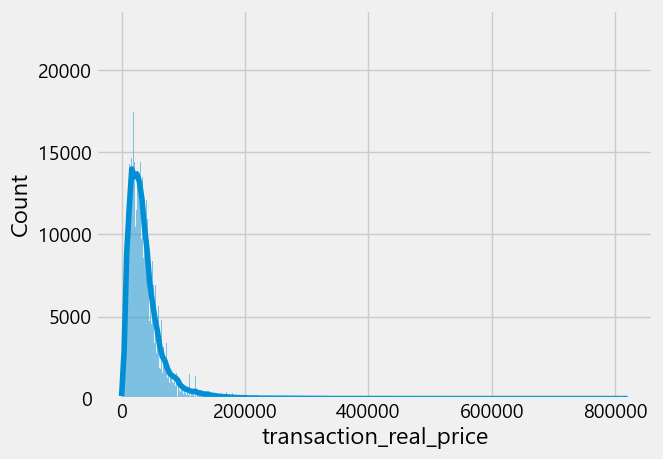

In [85]:
# 로그 변환
sns.histplot(train['transaction_real_price'], kde = True)
plt.show()




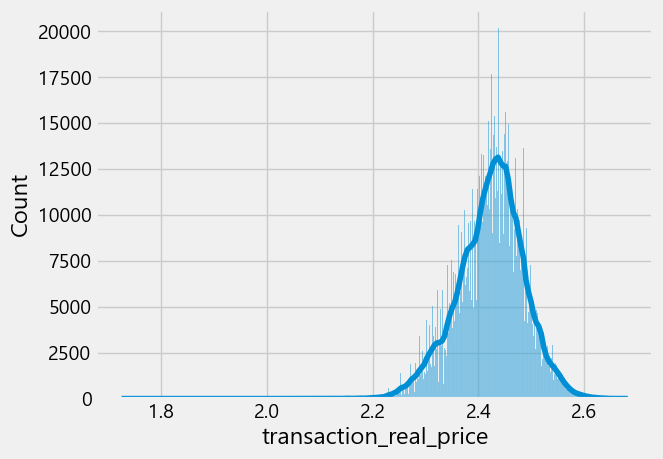

In [86]:
train['transaction_real_price'] = np.log1p(train['transaction_real_price'])
sns.histplot(np.log1p(train['transaction_real_price']), kde = True)
plt.show()

In [87]:
train = train.drop(['transaction_id','apartment_id','dong','jibun','addr_kr'], axis = 1)

train = train.drop(['transaction_year_month', 'year', 'month','year_of_completion', 'branded', 'price_per_area'], axis = 1)

In [88]:
# 범주형 데이터 처리
# 원 핫 인코딩
train_X_cat = train[['city', 'transaction_date']]


In [89]:
print(train.columns)

Index(['city', 'apt', 'exclusive_use_area', 'transaction_date', 'floor',
       'transaction_real_price', 'age', 'reconstruction'],
      dtype='object')


In [90]:
train_X_cat.head()

,city,transaction_date
0,서울특별시,21~31
1,서울특별시,1~10
2,서울특별시,1~10
3,서울특별시,11~20
4,서울특별시,21~31


In [91]:
# train 데이터의 수치형 컬럼을 추출해서 train_X_num 이라는 객체에 저장합니다.
train_X_num = train[['exclusive_use_area']]

In [92]:
# scikit-learn 패키지의 StandardScaler 클래스를 불러오기
from sklearn.preprocessing import StandardScaler

# StandardScaler 객체 생성
Standard_scaler = StandardScaler()


In [93]:
# fit_transform()을 사용해서 학습과 스케일링을 한번에 적용
train_standard = Standard_scaler.fit_transform(train_X_num)

# 표준화가 완료된 데이터를 데이터프레임 형태로 변환
train_standard = pd.DataFrame(train_standard, index=train_X_num.index,
                              columns=train_X_num.columns)
# 표준화 잘 적용되었는지 확인
train_standard.head()

,exclusive_use_area
0,0.228276
1,0.720539
2,0.225532
3,2.340374
4,3.988338


In [94]:
# 정규화
# scikit-learn 패키지의 MinMaxScaler 클래스 불러오기
from sklearn.preprocessing import MinMaxScaler

# MinMaxScaler 객체를 생성
minmax_scaler = MinMaxScaler()


In [95]:
# fit_transform()을 사용해서 학습과 스케일링을 한 번에 적용
train_minmax = minmax_scaler.fit_transform(train_X_num)

# Min-Max 스케일링이 완료된 데이터를 데이터 프레임 형태로 변환
train_minmax = pd.DataFrame(train_minmax, index = train_X_num.index, columns = train_X_num.columns)

In [96]:
# 스케일링이 잘 되었는지 데이터 확인 
train_minmax.head()

,exclusive_use_area
0,0.182046
1,0.216619
2,0.181853
3,0.330386
4,0.446128


train 데이터
    ↓
fit_transform()   ← 기준 생성 + 변환

test 데이터
    ↓
transform()       ← train 기준 그대로 적용

In [97]:
# 범주형 데이터 (One-Hot Encoding)
train_X_cat = train[['city', 'transaction_date']]
test_X_cat  = test[['city', 'transaction_date']]

train_X_cat = pd.get_dummies(train_X_cat)
test_X_cat  = pd.get_dummies(test_X_cat)

test_X_cat = test_X_cat.reindex(columns=train_X_cat.columns, fill_value=0)

In [98]:
# test 수치형 컬럼 추출
test_X_num = test[['exclusive_use_area']]

# train에서 만든 scaler 그대로 사용 (fit X)
test_minmax = minmax_scaler.transform(test_X_num)

test_minmax = pd.DataFrame(
    test_minmax,
    index=test_X_num.index,
    columns=train_X_num.columns
)

In [99]:
# 데이터 스케일링 적용
# 두 데이터 프레임을 열 방향(axis = 1)로 합치기
X = pd.concat([train_minmax, train_X_cat, train['apt']], axis = 1)

# 예측해야 하는 변수를 y라는 객체에 따로 저장
y = train['transaction_real_price']

In [100]:
# 테스트 데이터
X_test = pd.concat([test_minmax, test_X_cat, test[['apt']]], axis=1)
X_test = X_test.reindex(columns=X.columns, fill_value=0)

In [101]:
print(X.shape)
print(X_test.shape)
print((X.columns == X_test.columns).all())

(1216553, 7)
(5463, 7)
True


In [102]:
# 로버스트
# scikit-learn 패키지의 RobustScaler 클래스 불러오기
from sklearn.preprocessing import RobustScaler

# RobustScaler 객체 생성
robustScaler = RobustScaler()

# fit_transform()을 사용해 학습과 스케일링 한번에 적용
X_train_robust = robustScaler.fit_transform(train_X_num)

# robust 스케일링이 완료된 데이터를 데이터 프레임 형태로 변환
X_train_robust = pd.DataFrame(X_train_robust, index = train_X_num.index,
                              columns =train_X_num.columns)


In [103]:
print(type(test_X_num))
print(test_X_num.shape)

<class 'pandas.core.frame.DataFrame'>
(5463, 1)


In [104]:
print(type(test_minmax))
print(test_minmax.shape)

<class 'pandas.core.frame.DataFrame'>
(5463, 1)


In [105]:
X_test = pd.concat(
    [test_minmax, test_X_cat, test[['apt']]],
    axis=1
)

X_test = X_test.reindex(columns=X.columns, fill_value=0)

In [106]:
print(X.shape)
print(X_test.shape)
print((X.columns == X_test.columns).all())

(1216553, 7)
(5463, 7)
True


In [107]:
X.select_dtypes(include='object')

,apt
0,11
1,11
2,11
3,11
4,11
...,...
1216548,11
1216549,11
1216550,11
1216551,12


In [108]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
model_lr = lr.fit(X, y)

lr_pred = model_lr.predict(X_test)
print(lr_pred[:5])

[10.05704326  9.6534063   9.70107873 11.09486619 10.35126843]


In [109]:
# 독립변수의 계수를 확인
np.round(model_lr.coef_,1)


array([ 5.7, -0.4,  0.4,  0. , -0. ,  0. ,  0. ])

In [110]:
# 선형회귀의 y절편을 확인
np.round(model_lr.intercept_)

np.float64(9.0)

In [111]:
X.columns

Index(['exclusive_use_area', 'city_부산광역시', 'city_서울특별시',
       'transaction_date_11~20', 'transaction_date_1~10',
       'transaction_date_21~31', 'apt'],
      dtype='object')

In [112]:
# 랜덤 포레스트
# 변수 중요도 

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

model_rf = rf.fit(X,y)

rf_feature_importances = model_rf.feature_importances_
rf_feature_importances

array([0.56238259, 0.39974716, 0.        , 0.00149866, 0.00153529,
       0.00151968, 0.03331662])

In [113]:
X.columns

Index(['exclusive_use_area', 'city_부산광역시', 'city_서울특별시',
       'transaction_date_11~20', 'transaction_date_1~10',
       'transaction_date_21~31', 'apt'],
      dtype='object')

In [114]:
rf_feature_importances = pd.DataFrame(model_rf.feature_importances_, X.columns , columns= ['feature importance'])
rf_feature_importances

,feature importance
exclusive_use_area,0.562383
city_부산광역시,0.399747
city_서울특별시,0.000000
transaction_date_11~20,0.001499
transaction_date_1~10,0.001535
transaction_date_21~31,0.001520
apt,0.033317


# 컬럼명 다르게 나와서 전체 코딩 후 확인 필요 (그래프 수치도 다를 수 밖에 없음)

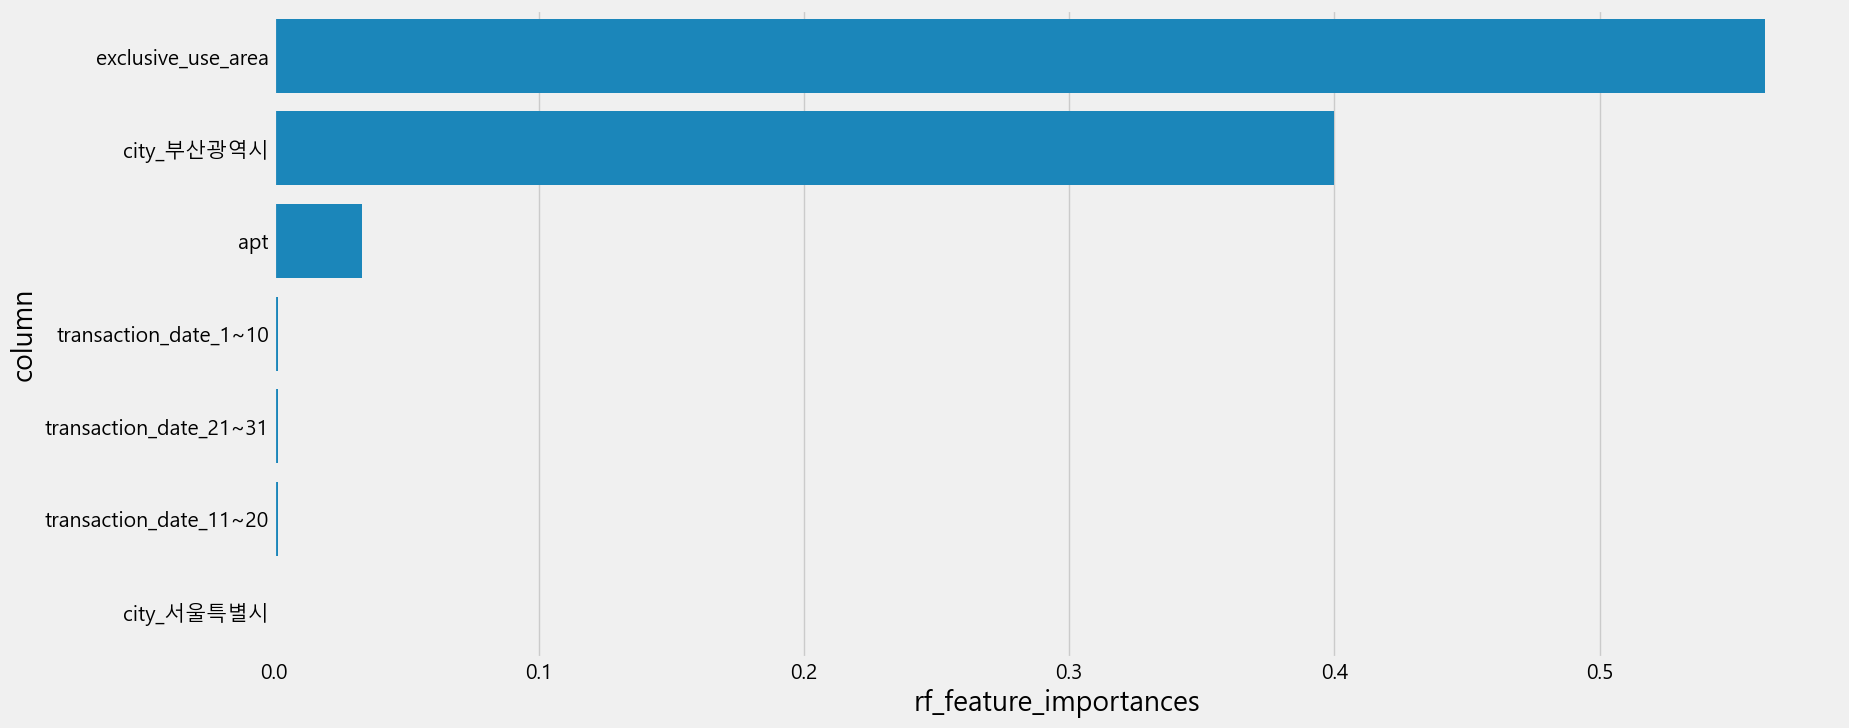

In [115]:
# 변수 중요도 순서 정렬
rf_feature_importances = rf_feature_importances.sort_values('feature importance', ascending = False)

plt.figure(figsize= (18, 8))
sns.barplot(x = 'feature importance', y = rf_feature_importances.index, orient='h',
            data=rf_feature_importances)

plt.xticks(size = 15)
plt.yticks(size = 15)

plt.xlabel('rf_feature_importances', size = 20)
plt.ylabel('column',size = 20)
plt.show()

In [116]:
# 하이퍼파라미터 튜닝
# 그리드 서치

from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)

from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV

In [117]:
# train 데이터와 validation 나누기
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test  = train_test_split(
    X, y, test_size= 0.2, random_state=42
)

In [118]:
# 성능평가
from sklearn.metrics import mean_squared_error


In [119]:
# RMSE 음수값 계산함수
def MINUS_RMSE(y_real, y_pred):
    return -mean_squared_error(y_real, y_pred)**0.5


In [120]:
# 그리드 서치의 파라미터 지정
params_grid = {
    'n_estimators' : [10,50],
    'min_samples_split': [2, 4, 6],
}

In [121]:
grid_cv = GridSearchCV(rf, param_grid=params_grid, cv = 2,
                       scoring=make_scorer(
                           MINUS_RMSE, greater_is_better=False
                       ))
grid_cv.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'min_samples_split': [2, 4, ...], 'n_estimators': [10, 50]}"
,scoring,make_scorer(M...hod='predict')
,n_jobs,None
,refit,True
,cv,2
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,10


In [122]:
print('best score : ', grid_cv.best_score_)
print('best parameters: ' , grid_cv.best_params_)
print('best estimator:', grid_cv.best_estimator_)

best score :  0.2674825732679573
best parameters:  {'min_samples_split': 2, 'n_estimators': 10}
best estimator: RandomForestRegressor(n_estimators=10, random_state=42)


In [123]:
from sklearn.model_selection import RandomizedSearchCV

In [124]:
# 랜덤서치의 파라미터 지정
params_random = {
    'n_estimators': [100],
    'max_depth': [6, 8, 10, 12],
    'max_leaf_nodes': [8, 12, 18],
    'min_samples_split': [8, 16, 20]  
}

In [125]:
random_cv = RandomizedSearchCV(rf, param_distributions=params_random, cv=2,
                                scoring=make_scorer(
                                    MINUS_RMSE, greater_is_better=False
                                ))
random_cv.fit(X_train, y_train)

,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [6, 8, ...], 'max_leaf_nodes': [8, 12, ...], 'min_samples_split': [8, 16, ...], 'n_estimators': [100]}"
,n_iter,10
,scoring,make_scorer(M...hod='predict')
,n_jobs,None
,refit,True
,cv,2
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [126]:
print('best score :', random_cv.best_score_)
print('best parameters:', random_cv.best_params_)
print('best estimator: ', random_cv.best_estimator_)

best score : 0.40460739657752914
best parameters: {'n_estimators': 100, 'min_samples_split': 8, 'max_leaf_nodes': 8, 'max_depth': 6}
best estimator:  RandomForestRegressor(max_depth=6, max_leaf_nodes=8, min_samples_split=8,
                      random_state=42)


In [127]:
# 홀드아웃
# scikit-learn 패키지의 train_test_split()을 불러옴
from sklearn.model_selection import train_test_split

# scikit-learn 패키지의 mean_squared_error 를 불러옴
from sklearn.metrics import mean_squared_error


In [128]:
# RMSE 계산 함수
def RMSE(y_real, y_pred):
    return mean_squared_error(y_real, y_pred)**0.5


In [129]:
# 모델 학습 & 예측
model_rf = rf.fit(X_train, y_train)

In [130]:
# 학습 데이터와 학습용과 검증용으로 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state= 42)

# 모델을 학습 하고 예측
model_rf = rf.fit(X_train, y_train)
rf_pred = model_rf.predict(X_test)

# 모델의 성능을 RMSE 로 측정
print(RMSE(y_test, rf_pred))


0.26138092514318345


In [131]:
# 계층적 k-fold 교차검증
# scikit-learn 패키지의 cross_val_score()를 불러옴
from sklearn.model_selection import cross_val_score


In [132]:
# scikit-learn 패키지의 k-fold 교차검증을 위한 클래스를 불러옴
from sklearn.model_selection import KFold


In [133]:
# 5개의 fold를 분리하여 kfold 객체에 할당 
kfold = KFold(n_splits=5, shuffle = True, random_state=42)


In [134]:
# 5 Fold 세트로 MSE 값을 구한 뒤, 이를 기반으로 다시 RMSE 를 계산
neg_mse_scores = cross_val_score(model_rf, X_train, y_train, scoring= 'neg_mean_squared_error',cv=kfold)
rmse_scores = np.sqrt(-1*neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

In [135]:
# 5 Fold 의 평균 RMSE 값을 출력
print(avg_rmse)

0.2619368944127768


In [136]:
# scoring 파라미터 
# 5 Fold 세트로 MSE 값을 구한 뒤, 이를 기반으로 다시 RMSE를 계산합니다.
neg_mse_scores = cross_val_score(model_rf, X_train, y_train,
                                 scoring= 'neg_mean_squared_error',cv = kfold)
rmse = scores = np.sqrt(-1*neg_mse_scores)

# 5개의 RMSE 값의 평균을 구하기 위해 numpy 패키지의 mean()을 활용
avg_rmse = np.mean(rmse_scores)

# 계산결과 출력
print('5 folds 의 개별 Negative MSE scores:', np.round(neg_mse_scores,4))
print('5 folds 의 개별 RMSE scores : ', np.round(rmse_scores,4))
print('5 folds 의 평균 RMSE : {0:.3f}'.format(avg_rmse))


5 folds 의 개별 Negative MSE scores: [-0.0688 -0.069  -0.0682 -0.0681 -0.069 ]
5 folds 의 개별 RMSE scores :  [0.2622 0.2627 0.2611 0.261  0.2626]
5 folds 의 평균 RMSE : 0.262


In [137]:
# 10 Fold 세트로 MAE를 구한 뒤(-1)을 곱해준 다음 평균 MAE 값을 계산한다.
neg_mae_scores = cross_val_score(model_rf, X_train, y_train, 
                                 scoring='neg_mean_absolute_error', cv = 10)
mae_score = (-1)*neg_mae_scores

avg_mae = np.mean(mae_score)

# 평균 MAE 값을 출력합니다.
print(avg_mae)

0.18817561306113875


In [138]:
from sklearn.ensemble import AdaBoostRegressor

ad = AdaBoostRegressor(random_state= 42)

# RMSE
def RMSE(y_real, y_pred):
    return mean_squared_error(y_real, y_pred)**0.5

In [139]:
model_ad = ad.fit(X_train, y_train)
ad_pred = model_ad.predict(X_test)

In [140]:
print('AdaBoostRegressor', RMSE(ad_pred, y_test))

AdaBoostRegressor 0.40436459385197987


In [141]:
ad.feature_importances_

array([0.62928716, 0.34448358, 0.00318864, 0.0092927 , 0.        ,
       0.00510941, 0.00863851])

In [142]:
X.columns

Index(['exclusive_use_area', 'city_부산광역시', 'city_서울특별시',
       'transaction_date_11~20', 'transaction_date_1~10',
       'transaction_date_21~31', 'apt'],
      dtype='object')

In [143]:
ad_feature_importance = pd.DataFrame(ad.feature_importances_, X.columns, columns = ['feature importance'])

In [144]:
ad_feature_importance

,feature importance
exclusive_use_area,0.629287
city_부산광역시,0.344484
city_서울특별시,0.003189
transaction_date_11~20,0.009293
transaction_date_1~10,0.000000
transaction_date_21~31,0.005109
apt,0.008639


In [145]:
ad_feature_importance = ad_feature_importance.sort_values('feature importance', ascending= False)

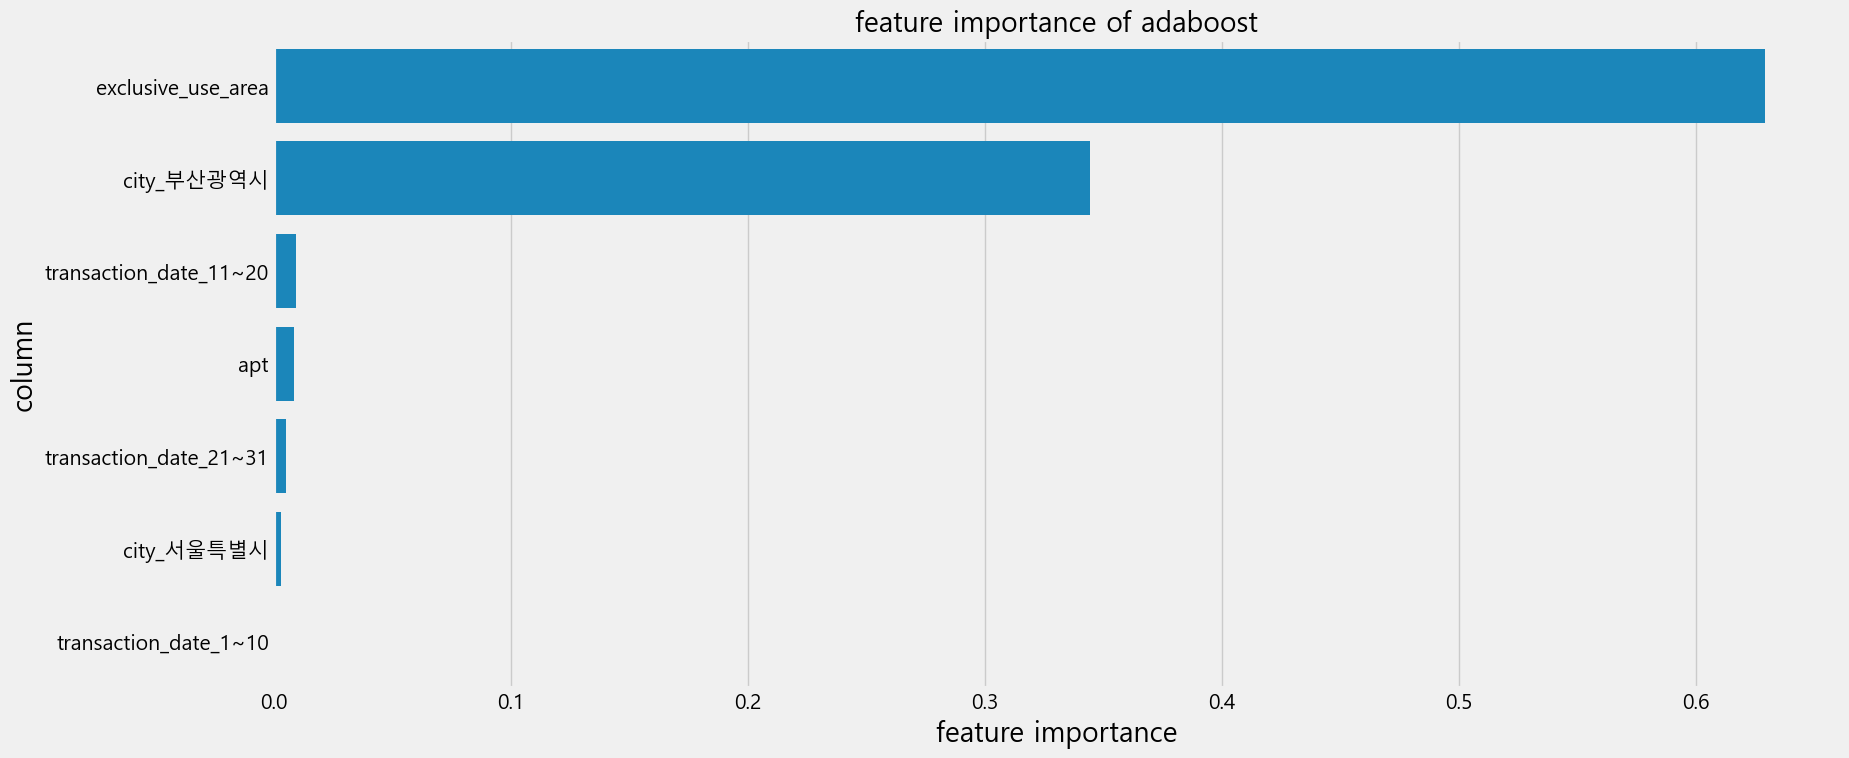

In [146]:
# seaborn 의 barplot 을 이용하여 변수의 중요도를 순서대로
plt.figure(figsize=(18, 8))
sns.barplot(x='feature importance', y=ad_feature_importance.index, orient='h', data=ad_feature_importance)
plt.title('feature importance of adaboost', size=20)

plt.xticks(size=15)
plt.yticks(size=15)

plt.xlabel('feature importance', size=20)
plt.ylabel('column', size=20)
plt.show()

In [147]:
ad_feature_importance.columns

Index(['feature importance'], dtype='object')

In [148]:
# GBM 실습
from sklearn.ensemble import GradientBoostingRegressor

In [149]:
gbm = GradientBoostingRegressor(random_state= 42)

In [150]:
model_gbm = gbm.fit(X_train, y_train)

In [151]:
gbm_pred = model_gbm.predict(X_test)

In [152]:
print('gradient boosting Regressor', RMSE(gbm_pred, y_test))

gradient boosting Regressor 0.3759141281047643


In [153]:
gbm.feature_importances_

array([5.00316984e-01, 3.13671720e-01, 1.76528664e-01, 0.00000000e+00,
       3.19936100e-05, 2.21734385e-05, 9.42846525e-03])

In [154]:
gbm_feature_importance = pd.DataFrame(gbm.feature_importances_,
                                      X_test.columns,
                                      columns=['feature importance'])


In [155]:
gbm_feature_importance

,feature importance
exclusive_use_area,0.500317
city_부산광역시,0.313672
city_서울특별시,0.176529
transaction_date_11~20,0.000000
transaction_date_1~10,0.000032
transaction_date_21~31,0.000022
apt,0.009428


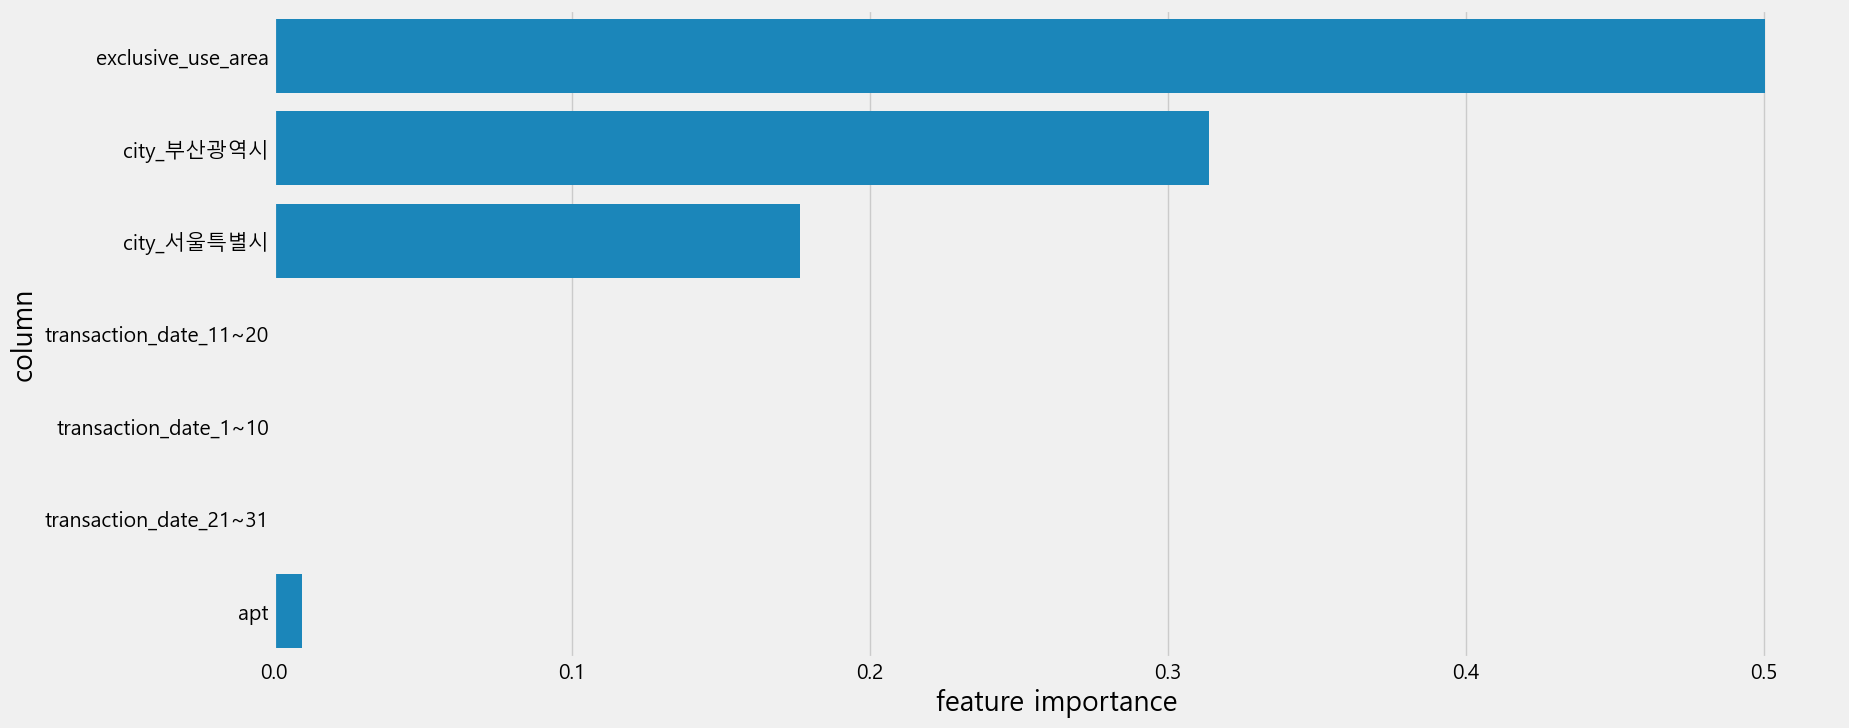

In [156]:
# seaborn 의 barplot 을 이용하여 변수의 중요도 순서대로 나타내보기
plt.figure(figsize= (18, 8))
sns.barplot(x = 'feature importance', y = gbm_feature_importance.index, orient='h',
            data = gbm_feature_importance)
plt.xticks(size = 15)
plt.yticks(size = 15)

plt.xlabel('feature importance', size = 20)
plt.ylabel('column', size = 20)
plt.show()

In [157]:
# XGBoost 하이퍼 파라미터

from xgboost import XGBRegressor

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train,
                                            test_size= 0.25, random_state=42)



In [158]:
X_tr.dtypes

exclusive_use_area        float64
city_부산광역시                   bool
city_서울특별시                   bool
transaction_date_11~20       bool
transaction_date_1~10        bool
transaction_date_21~31       bool
apt                        object
dtype: object

In [159]:
X_tr['apt'] = X_tr['apt'].astype('int')
X_val['apt'] = X_val['apt'].astype('int')

In [160]:
xgb = XGBRegressor(objective='reg:squarederror', random_state=42, 
                   eval_metric='rmse', early_stopping_rounds=50)

model_xgb = xgb.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_val, y_val)])

[0]	validation_0-rmse:0.56300	validation_1-rmse:0.56564
[1]	validation_0-rmse:0.47824	validation_1-rmse:0.48046
[2]	validation_0-rmse:0.42975	validation_1-rmse:0.43166
[3]	validation_0-rmse:0.40258	validation_1-rmse:0.40414
[4]	validation_0-rmse:0.38808	validation_1-rmse:0.38941
[5]	validation_0-rmse:0.38051	validation_1-rmse:0.38164
[6]	validation_0-rmse:0.37611	validation_1-rmse:0.37714
[7]	validation_0-rmse:0.37344	validation_1-rmse:0.37437
[8]	validation_0-rmse:0.37184	validation_1-rmse:0.37268
[9]	validation_0-rmse:0.37069	validation_1-rmse:0.37148
[10]	validation_0-rmse:0.36950	validation_1-rmse:0.37030
[11]	validation_0-rmse:0.36864	validation_1-rmse:0.36942
[12]	validation_0-rmse:0.36809	validation_1-rmse:0.36886
[13]	validation_0-rmse:0.36757	validation_1-rmse:0.36832
[14]	validation_0-rmse:0.36685	validation_1-rmse:0.36759
[15]	validation_0-rmse:0.36651	validation_1-rmse:0.36729
[16]	validation_0-rmse:0.36614	validation_1-rmse:0.36691
[17]	validation_0-rmse:0.36538	validation

In [164]:
xgb_pred = model_xgb.predict(X_test)

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:apt: object

In [163]:
# object 컬럼 확인
obj_cols = X_test.select_dtypes(include=["object"]).columns
print("object cols:", list(obj_cols))

# (겸사겸사) 전체 dtype 확인
print(X_test.dtypes)

object cols: ['apt']
exclusive_use_area        float64
city_부산광역시                   bool
city_서울특별시                   bool
transaction_date_11~20       bool
transaction_date_1~10        bool
transaction_date_21~31       bool
apt                        object
dtype: object


In [ ]:
# # apt 컬럼 제외하고 인코딩
# X_train_enc = pd.get_dummies(X_train, columns=[c for c in X_train.columns if c != 'apt'])
# X_test_enc  = pd.get_dummies(X_test,  columns=[c for c in X_test.columns  if c != 'apt'])

# X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)
# xgb_pred = model_xgb.predict(X_test_enc)

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:apt: object

In [165]:

X_test_fixed = X_test.copy()
X_test_fixed['apt'] = X_test_fixed['apt'].astype(int)

print(X_test_fixed.dtypes)  # 확인용
xgb_pred = model_xgb.predict(X_test_fixed)
print(xgb_pred[:5])

exclusive_use_area        float64
city_부산광역시                   bool
city_서울특별시                   bool
transaction_date_11~20       bool
transaction_date_1~10        bool
transaction_date_21~31       bool
apt                         int64
dtype: object
[10.176713 10.362955 11.026827 10.190069 10.148172]


In [167]:
pip install lightgbm

In [168]:
# LGBM
from lightgbm import LGBMRegressor
lgb = LGBMRegressor(random_state = 42)

# light gbm에서 자체 검증을 사용하여 모델 학습 수행하기
model_gbm = lgb.fit(X_tr, y_tr, eval_set = [(X_tr, y_tr), (X_val, y_val)], eval_metric = 'rmse', early_stopping_rounds = 50)
lgb_pred = model_lgb.predict(X_test)

print('LGB', RMSE (lgb_pred, y_test))

TypeError: LGBMRegressor.fit() got an unexpected keyword argument 'early_stopping_rounds'

In [169]:
%who

AdaBoostRegressor	 GradientBoostingRegressor	 GridSearchCV	 KFold	 LGBMRegressor	 LinearRegression	 MINUS_RMSE	 MinMaxScaler	 RMSE	 
RandomForestRegressor	 RandomizedSearchCV	 RobustScaler	 StandardScaler	 Standard_scaler	 X	 XGBRegressor	 X_test	 X_test_fixed	 
X_tr	 X_train	 X_train_robust	 X_val	 ad	 ad_feature_importance	 ad_pred	 apt	 apt_brand_list	 
apt_price	 apt_price_le	 avg_mae	 avg_rmse	 brand	 busan_data	 color	 cor	 cross_val_score	 
gbm	 gbm_feature_importance	 gbm_pred	 grid_cv	 i	 kfold	 langs	 lgb	 lr	 
lr_pred	 mae_score	 make_scorer	 mean_squared_error	 minmax_scaler	 model_ad	 model_gbm	 model_lr	 model_rf	 
model_xgb	 neg_mae_scores	 neg_mse_scores	 np	 obj_cols	 order	 params_grid	 params_random	 pd	 
plt	 price_busan_dong	 price_busan_dong_top_10	 price_per_area_by_year	 price_seoul_dong	 price_seoul_dong_top_10	 random_cv	 re	 regex	 
rf	 rf_feature_importances	 rf_pred	 rmse	 rmse_scores	 robustScaler	 scores	 seoul_busan	 seoul_data	 
sns	 test	 test_X_cat	 t

In [170]:
print(X_tr.shape, X_val.shape, X_test_fixed.shape)
print(y_tr.shape, y_val.shape, y_test.shape)

(729931, 7) (243311, 7) (243311, 7)
(729931,) (243311,) (243311,)


In [171]:
from lightgbm import LGBMRegressor, early_stopping

lgb = LGBMRegressor(random_state=42)

model_gbm = lgb.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric="rmse",
    callbacks=[early_stopping(50)]
)

lgb_pred = model_gbm.predict(X_test_fixed)

print("LGB", RMSE(y_test, lgb_pred))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004762 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 285
[LightGBM] [Info] Number of data points in the train set: 729931, number of used features: 7
[LightGBM] [Info] Start training from score 10.304514
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[100]	valid_0's rmse: 0.361621	valid_0's l2: 0.130769
LGB 0.36297323285177485
